# Federated Learning â€” Full Pipeline Federation (TCN + GAT + CaT-GNN + DAE + GatedFusion)

**Architecture:** All five encoder components are federated across 3 financial institutions.
Each institution trains the FULL fraud-detection pipeline on its local data.

**Federated components:**
- `FraudTCN` (PyTorch) â€” temporal/tabular feature encoder â†’ 64-d
- `FraudGAT` (DGL, 2-layer) â€” relational graph encoder â†’ 64-d
- `CaT_GNN` (DGL, 1-layer) â€” causal temporal graph encoder â†’ 64-d
- `ImprovedDAE` â€” denoising autoencoder â†’ 64-d
- `GatedFusion + FusionClassifier` â€” learned fusion head â†’ fraud probability

**Algorithms:** FedAvg â†’ FedProx â†’ FedNova (run sequentially)

**Local training per round per client:**
1. Graph phase: train GAT + CaT-GNN on local GTAN graph
2. Fusion phase: extract graph embeddings (no-grad) â†’ train TCN + DAE + GatedFusion


## Cell 1 â€” Imports & GPU Setup

In [1]:
rm -rf /kaggle/working/*

In [2]:
!pip install dgl -f https://data.dgl.ai/wheels/torch-2.1/cu121/repo.html -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 483.2/483.2 MB 3.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.2/797.2 MB 1.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 76.6 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 63.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 42.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 34.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 15.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 8.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━

In [3]:
import os, sys, copy, io, gzip, json, time, warnings

# Must be set before importing torch â€” disables dynamo without touching the broken module
os.environ['TORCHDYNAMO_DISABLE'] = '1'

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path
warnings.filterwarnings('ignore')

import dgl
import dgl.dataloading
from dgl.nn.pytorch import GATConv

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed(SEED)
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Device: {DEVICE}')

# PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
DATA_DIR     = Path('/kaggle/input/competitions/ieee-fraud-detection')
FL_RESULTS   = Path('/kaggle/working/fl-results')
os.makedirs(FL_RESULTS, exist_ok=True)
os.makedirs(os.path.join(FL_RESULTS, 'models'), exist_ok=True)
print(f'Results: {FL_RESULTS}')

DGL backend not selected or invalid.  Assuming PyTorch for now.


Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)
GPU: Tesla T4
Device: cuda
Results: /kaggle/working/fl-results


## Cell 2 â€” FL Configuration

In [4]:
FL_CONFIG = {
    'num_rounds':             100,
    'client_fraction':        1.0,
    'min_clients_per_round':  3,

    # Longer than the first successful 0.9171 run; LR decay needs recovery room.
    'patience':               30,
    'min_delta':              5e-4,

    # Round-level LR schedule. Local optimizers are recreated each round.
    'lr':                     1e-3,
    'lr_patience':            5,
    'lr_factor':              0.5,
    'min_lr':                 1e-6,

    # Architecture (matches experiment_fusion)
    'input_dim':   263,
    'embed_dim':   64,
    'gat_heads':   4,
    'dropout':     0.3,

    # Graph construction
    'graph_k':         3,
    'graph_max_group': 500,

    # Local training
    'local_epochs':        2,
    'batch_size':          1024,
    'gat_fan_out':         [10, 5],
    'catgnn_fan_out':      [15],
    'max_grad_norm':       1.0,

    # DAE 2-phase semi-supervised training (mirrors experiment_dae)
    'dae_pretrain_epochs':  1,
    'dae_pretrain_lr':      1e-3,
    'dae_min_pretrain_lr':  1e-6,
    'dae_weight_decay':     1e-4,
    'dae_mask_ratio':       0.30,
    'dae_finetune_epochs':  1,
    'dae_finetune_lr':      5e-4,
    'dae_min_finetune_lr':  5e-7,
    'dae_recon_weight':     0.1,

    # FL algorithms
    'algorithms':  ['fedavg', 'fedprox', 'fednova'],
    'fedprox_mu':  0.01,

    # Enhancement 1: FedBN (Li et al., ICLR 2021)
    # Keep BatchNorm running stats local. Different transaction volume
    # distributions per institution make shared BN stats harmful.
    'fedbn_enabled':          True,

    # Privacy/stability toggles
    'byzantine_enabled': False,
    'dp_enabled':        False,

    # Loss
    'pos_weight': 27.0,
}
print('FL Configuration (dynamic round LR + longer patience + FedBN):')
for k, v in FL_CONFIG.items():
    print(f'  {k:28s}: {v}')


FL Configuration (dynamic round LR + longer patience + FedBN):
  num_rounds                  : 100
  client_fraction             : 1.0
  min_clients_per_round       : 3
  patience                    : 30
  min_delta                   : 0.0005
  lr                          : 0.001
  lr_patience                 : 5
  lr_factor                   : 0.5
  min_lr                      : 1e-06
  input_dim                   : 263
  embed_dim                   : 64
  gat_heads                   : 4
  dropout                     : 0.3
  graph_k                     : 3
  graph_max_group             : 500
  local_epochs                : 2
  batch_size                  : 1024
  gat_fan_out                 : [10, 5]
  catgnn_fan_out              : [15]
  max_grad_norm               : 1.0
  dae_pretrain_epochs         : 1
  dae_pretrain_lr             : 0.001
  dae_min_pretrain_lr         : 1e-06
  dae_weight_decay            : 0.0001
  dae_mask_ratio              : 0.3
  dae_finetune_epochs         :

## Cell 3 â€” Weighted BCE Loss

In [5]:
pos_weight_tensor = torch.tensor([FL_CONFIG['pos_weight']], dtype=torch.float32)

def weighted_bce_loss(logits, targets):
    pw = pos_weight_tensor.to(logits.device)
    return F.binary_cross_entropy_with_logits(logits, targets.float(), pos_weight=pw)

print('weighted_bce_loss defined (pos_weight=27.0)')

weighted_bce_loss defined (pos_weight=27.0)


## Cell 4 â€” FraudTCN (identical to experiment_tcn: dilated causal TCN, seq=20, filters=128)

In [6]:
class TCNBlock(nn.Module):
    """Temporal block: two causal dilated Conv1d + residual skip (mirrors experiment_tcn TCNBlock)."""
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout=0.2):
        super().__init__()
        self.causal_pad = (kernel_size - 1) * dilation
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, dilation=dilation)
        self.bn1   = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, dilation=dilation)
        self.bn2   = nn.BatchNorm1d(out_ch)
        self.drop  = nn.Dropout(dropout)
        self.skip  = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        nn.init.kaiming_normal_(self.conv1.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.conv2.weight, nonlinearity='relu')

    def forward(self, x):
        out = self.drop(F.relu(self.bn1(self.conv1(F.pad(x, (self.causal_pad, 0))))))
        out = self.drop(F.relu(self.bn2(self.conv2(F.pad(out, (self.causal_pad, 0))))))
        return F.relu(out + self.skip(x))


class FraudTCN(nn.Module):
    """
    PyTorch TCN â€” identical to experiment_tcn.ipynb.
    Input:  (N, 263) -> zero-pad to (N, 280) -> reshape (N, 20, 14) -> permute (N, 14, 20)
    TCN:    nb_filters=128, kernel_size=3, dilations=[1,2,4,8], skip connections, batch norm
    Dense:  DENSE_UNITS=[128, 64, 32]; embedding = dense2+BN output (dense_2 equivalent)
    """
    SEQ_LEN  = 20   # SEQUENCE_LENGTH
    PAD_DIM  = 280  # 263 + 17 padding -> 20 Ã— 14
    FEAT_DIM = 14   # features per timestep

    def __init__(self, input_dim=263, embed_dim=64,
                 nb_filters=128, kernel_size=3, dilations=(1, 2, 4, 8), dropout=0.2):
        super().__init__()
        in_ch = self.FEAT_DIM
        self.tcn_blocks = nn.ModuleList()
        for d in dilations:
            self.tcn_blocks.append(TCNBlock(in_ch, nb_filters, kernel_size, d, dropout))
            in_ch = nb_filters

        # Dense head: [128, 64 (embed), 32]  â€”  matches DENSE_UNITS in experiment_tcn
        self.dense1 = nn.Linear(nb_filters, 128);  self.bn_d1 = nn.BatchNorm1d(128)
        self.drop1  = nn.Dropout(dropout)
        self.dense2 = nn.Linear(128, embed_dim);   self.bn_d2 = nn.BatchNorm1d(embed_dim)
        self.drop2  = nn.Dropout(dropout)
        self.dense3 = nn.Linear(embed_dim, 32);    self.bn_d3 = nn.BatchNorm1d(32)
        self.drop3  = nn.Dropout(dropout)
        self.output_layer = nn.Linear(32, 1)

    def _reshape(self, x):
        n = x.shape[0]
        x = F.pad(x, (0, self.PAD_DIM - x.shape[1]))          # (N, 280)
        return x.view(n, self.SEQ_LEN, self.FEAT_DIM).permute(0, 2, 1).contiguous()  # (N,14,20)

    def forward(self, x):
        h = self._reshape(x)
        skip_sum = None
        for block in self.tcn_blocks:
            h = block(h)
            skip_sum = h if skip_sum is None else skip_sum + h
        h = skip_sum[:, :, -1]                                 # last timestep -> (N, 128)
        h = self.drop1(F.relu(self.bn_d1(self.dense1(h))))
        z = F.relu(self.bn_d2(self.dense2(h)))                 # embedding (dense_2 equivalent)
        return z

    def encode(self, x):
        return self.forward(x)

print('FraudTCN defined (identical to experiment_tcn: 263->pad280->(N,14,20)->TCN[1,2,4,8]->dense[128,64])')

FraudTCN defined (identical to experiment_tcn: 263->pad280->(N,14,20)->TCN[1,2,4,8]->dense[128,64])


## Cell 5 â€” FraudGAT (identical to experiment_gat)

In [7]:
class FraudGAT(nn.Module):
    """2-layer GAT â€” identical to experiment_gat.ipynb."""
    def __init__(self, in_dim=263, hidden_dim=64, num_heads=4, feat_drop=0.3, attn_drop=0.3):
        super().__init__()
        self.gat1 = GATConv(in_dim, hidden_dim, num_heads, feat_drop, attn_drop,
                             activation=F.elu, residual=False, allow_zero_in_degree=True)
        self.bn1  = nn.BatchNorm1d(hidden_dim * num_heads)
        self.gat2 = GATConv(hidden_dim*num_heads, hidden_dim, 1, feat_drop, attn_drop,
                             activation=None, residual=True, allow_zero_in_degree=True)
        self.bn2  = nn.BatchNorm1d(hidden_dim)
        self.drop = nn.Dropout(feat_drop)

    def forward(self, blocks, x):
        h = self.gat1(blocks[0], x).flatten(1)
        h = self.drop(self.bn1(h))
        h = self.gat2(blocks[1], h).squeeze(1)
        return self.bn2(h)

    def forward_full(self, g, x):
        h = self.gat1(g, x).flatten(1)
        h = self.drop(self.bn1(h))
        h = self.gat2(g, h).squeeze(1)
        return self.bn2(h)

print('FraudGAT: in_dim -> 64x4 -> 64 (2-layer GAT)')

FraudGAT: in_dim -> 64x4 -> 64 (2-layer GAT)


## Cell 6 â€” CausalInspector + CausalIntervener + CaT_GNN (identical to experiment_catgnn)

In [8]:
class CausalInspector(nn.Module):
    """Causal attention inspector with 5-fix patches (RC-1..RC-5)."""
    def __init__(self, in_dim=263, hidden_dim=64, num_heads=4, feat_drop=0.3, attn_drop=0.3):
        super().__init__()
        embed_dim = hidden_dim * 2
        self.feat_embed = nn.Sequential(
            nn.Linear(in_dim, embed_dim), nn.LayerNorm(embed_dim),
            nn.ReLU(), nn.Dropout(feat_drop))
        self.attn_layer = GATConv(embed_dim, hidden_dim, num_heads, feat_drop, attn_drop,
                                   activation=F.elu, residual=False, allow_zero_in_degree=True)
        self.causal_proj = nn.Sequential(nn.Linear(embed_dim, hidden_dim), nn.ReLU())
        self.env_proj    = nn.Sequential(nn.Linear(embed_dim, hidden_dim), nn.ReLU())

    def forward(self, g, h):
        if g.is_block:
            n_dst   = g.num_dst_nodes()
            h_embed = self.feat_embed(h)
            _, attn = self.attn_layer(g, (h_embed, h_embed[:n_dst]), get_attention=True)
            h_src   = h_embed
        else:
            n_dst   = g.num_nodes()
            h_embed = self.feat_embed(h)
            _, attn = self.attn_layer(g, h_embed, get_attention=True)
            h_src   = h_embed
        # Cast to float32 â€” autocast may produce float16 attention weights,
        # which breaks scatter_add_ against float32 accumulators.
        edge_imp = attn.mean(dim=1).squeeze(-1).float()
        h_src    = h_src.float()
        src_idx, dst_idx = g.edges()
        dst_sum = torch.zeros(n_dst, device=edge_imp.device)
        dst_cnt = torch.zeros(n_dst, device=edge_imp.device)
        dst_sum.scatter_add_(0, dst_idx, edge_imp)
        dst_cnt.scatter_add_(0, dst_idx, torch.ones_like(edge_imp))
        thr = (dst_sum / (dst_cnt + 1e-8))[dst_idx]
        c_w = edge_imp * (edge_imp >= thr).float()
        e_w = (thr - edge_imp).clamp(min=0) * (edge_imp < thr).float()
        D   = h_src.shape[-1]
        de  = dst_idx.unsqueeze(-1).expand(-1, D)
        hcs = torch.zeros(n_dst, D, device=h_src.device)
        hes = torch.zeros(n_dst, D, device=h_src.device)
        cws = torch.zeros(n_dst, device=h_src.device)
        ews = torch.zeros(n_dst, device=h_src.device)
        hcs.scatter_add_(0, de, h_src[src_idx] * c_w.unsqueeze(-1))
        hes.scatter_add_(0, de, h_src[src_idx] * e_w.unsqueeze(-1))
        cws.scatter_add_(0, dst_idx, c_w)
        ews.scatter_add_(0, dst_idx, e_w)
        hca = hcs / (cws.unsqueeze(-1) + 1e-8)
        hea = hes / (ews.unsqueeze(-1) + 1e-8)
        nc, ne = (cws == 0).unsqueeze(-1), (ews == 0).unsqueeze(-1)
        if nc.any() or ne.any():
            ha = torch.zeros(n_dst, D, device=h_src.device)
            ac = torch.zeros(n_dst, device=h_src.device)
            ha.scatter_add_(0, de, h_src[src_idx])
            ac.scatter_add_(0, dst_idx, torch.ones_like(c_w))
            ha = ha / (ac.unsqueeze(-1) + 1e-8)
            hca = torch.where(nc, ha, hca)
            hea = torch.where(ne, ha, hea)
        return self.causal_proj(hca), self.env_proj(hea)


class CausalIntervener(nn.Module):
    """PL-variant: learned blend during training, identity at inference."""
    def __init__(self, hidden_dim=64):
        super().__init__()
        self.blend_net = nn.Sequential(
            nn.Linear(hidden_dim*2, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, 2))

    def forward(self, h_causal, h_env):
        if self.training:
            w = F.softmax(self.blend_net(torch.cat([h_causal, h_env], dim=-1)), dim=-1)
            return w[:,0:1]*h_causal + w[:,1:2]*h_env
        return h_env


class CaT_GNN(nn.Module):
    """Full CaT-GNN matching experiment_catgnn.ipynb (all 5 RC fixes applied).
    RC-4 fix: LayerNorm on inspector outputs before intervener +
              cat([h_causal, h_env_intervened]) -> Linear(128->64) instead of element-wise sum.
    """
    def __init__(self, in_dim=263, hidden_dim=64, num_heads=4, feat_drop=0.3, attn_drop=0.3):
        super().__init__()
        self.inspector  = CausalInspector(in_dim, hidden_dim, num_heads, feat_drop, attn_drop)
        self.intervener = CausalIntervener(hidden_dim)
        # RC-4: normalize before intervener; concatenate instead of element-wise sum
        self.ln_causal   = nn.LayerNorm(hidden_dim)
        self.ln_env      = nn.LayerNorm(hidden_dim)
        self.combine     = nn.Linear(hidden_dim * 2, hidden_dim)  # 128 -> 64
        self.norm        = nn.LayerNorm(hidden_dim)
        self.output_proj = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(feat_drop))

    def forward(self, block_or_graph, x):
        h_causal, h_env = self.inspector(block_or_graph, x)
        # RC-4: normalize before intervener (prevents scale collapse)
        h_causal = self.ln_causal(h_causal)
        h_env    = self.ln_env(h_env)
        h_env_i  = self.intervener(h_causal, h_env)
        # RC-4: concatenate -> project (more expressive than element-wise sum)
        h = F.relu(self.combine(torch.cat([h_causal, h_env_i], dim=-1)))
        return self.output_proj(self.norm(h))

print('CausalInspector, CausalIntervener, CaT_GNN defined (RC-1..RC-5 all applied).')

CausalInspector, CausalIntervener, CaT_GNN defined (RC-1..RC-5 all applied).


## Cell 7 â€” ImprovedDAE (identical to experiment_dae)

In [9]:
class ImprovedDAE(nn.Module):
    """Denoising Autoencoder â€” identical to experiment_dae.ipynb."""
    def __init__(self, input_dim=263, latent_dim=64, mask_ratio=0.30, dropout=0.3):
        super().__init__()
        self.mask_ratio = mask_ratio
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 512), nn.BatchNorm1d(512), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(512, 256),       nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, latent_dim), nn.LayerNorm(latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.BatchNorm1d(128), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(128, 256),        nn.BatchNorm1d(256), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(256, 512),        nn.BatchNorm1d(512), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(512, input_dim),
        )
        self.classifier = nn.Sequential(
            nn.Linear(latent_dim, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1))

    def mask_features(self, x):
        mask = torch.bernoulli(torch.full(x.shape, 1 - self.mask_ratio, device=x.device))
        return x * mask

    def encode(self, x):
        return self.encoder(x)

    def forward(self, x):
        x_in    = self.mask_features(x) if self.training else x
        z       = self.encoder(x_in)
        x_recon = self.decoder(z)
        return x_recon, z

print('ImprovedDAE: 263 -> 512 -> 256 -> 128 -> 64')

ImprovedDAE: 263 -> 512 -> 256 -> 128 -> 64


## Cell 8 â€” GatedFusion + FusionClassifier (identical to experiment_fusion)

In [10]:
class GatedFusion(nn.Module):
    """Gated Attention Fusion â€” 4-encoder variant (TCN + GAT + CaT-GNN + DAE)."""
    def __init__(self, embed_dim=64, proj_dim=128, dropout=0.3):
        super().__init__()
        self.proj_tcn    = nn.Sequential(nn.Linear(embed_dim, proj_dim), nn.ReLU(), nn.Dropout(dropout))
        self.proj_gat    = nn.Sequential(nn.Linear(embed_dim, proj_dim), nn.ReLU(), nn.Dropout(dropout))
        self.proj_catgnn = nn.Sequential(nn.Linear(embed_dim, proj_dim), nn.ReLU(), nn.Dropout(dropout))
        self.proj_dae    = nn.Sequential(nn.Linear(embed_dim, proj_dim), nn.ReLU(), nn.Dropout(dropout))
        self.gate     = nn.Sequential(
            nn.Linear(proj_dim*4, 128), nn.ReLU(), nn.Dropout(dropout), nn.Linear(128, 4))
        self.out_proj = nn.Sequential(
            nn.Linear(proj_dim, embed_dim), nn.ReLU(), nn.Dropout(dropout))
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, h_tcn, h_gat, h_catgnn, h_dae):
        pt = self.proj_tcn(h_tcn);   pg = self.proj_gat(h_gat)
        pc = self.proj_catgnn(h_catgnn); pd = self.proj_dae(h_dae)
        w  = F.softmax(self.gate(torch.cat([pt,pg,pc,pd], dim=-1)), dim=-1)
        fused = w[:,0:1]*pt + w[:,1:2]*pg + w[:,2:3]*pc + w[:,3:4]*pd
        return self.norm(self.out_proj(fused)), w


class FusionClassifier(nn.Module):
    def __init__(self, embed_dim=64):
        super().__init__()
        self.fusion = GatedFusion(embed_dim=embed_dim)
        self.head   = nn.Sequential(
            nn.Linear(embed_dim, 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1))

    def forward(self, h_tcn, h_gat, h_cat, h_dae):
        fused, w = self.fusion(h_tcn, h_gat, h_cat, h_dae)
        return self.head(fused), w

print('GatedFusion + FusionClassifier defined (4-encoder, identical to experiment_fusion).')

GatedFusion + FusionClassifier defined (4-encoder, identical to experiment_fusion).


## Cell 9 â€” Graph Builder (GTAN, identical to experiment_gat)

In [11]:
def build_gtan_graph(n_nodes, relation_series_dict, k=3, max_group=5000):
    src_list, dst_list = [], []
    for rel_name, series in relation_series_dict.items():
        n_before = len(src_list)
        skipped_large = skipped_nan = 0
        for group_val, group_idx in series.groupby(series).groups.items():
            if pd.isna(group_val) or str(group_val) in ('-1', 'nan'):
                skipped_nan += 1; continue
            indices = list(group_idx)
            if len(indices) < 2: continue
            if len(indices) > max_group:
                skipped_large += 1; continue
            for i in range(1, len(indices)):
                dst = indices[i]
                for src in indices[max(0, i-k):i]:
                    src_list.append(src); dst_list.append(dst)
        print(f'  [{rel_name}] edges={len(src_list)-n_before:,}  '
              f'skipped_large={skipped_large}  skipped_nan={skipped_nan}')
    if len(src_list) == 0:
        g = dgl.graph(([], []), num_nodes=n_nodes)
    else:
        g = dgl.graph((np.array(src_list, dtype=np.int64),
                       np.array(dst_list, dtype=np.int64)), num_nodes=n_nodes)
    g = dgl.add_reverse_edges(g)
    g = dgl.add_self_loop(g)
    print(f'Graph: {g.num_nodes():,} nodes, {g.num_edges():,} edges  '
          f'(avg_degree={g.num_edges()/g.num_nodes():.1f})')
    return g

print('build_gtan_graph defined.')

build_gtan_graph defined.


## Cell 10 â€” Data Loading & Preprocessing

In [12]:
print('Loading IEEE-CIS transaction data...')
df_trans = pd.read_csv(os.path.join(DATA_DIR, 'train_transaction.csv'))
df_ident = pd.read_csv(os.path.join(DATA_DIR, 'train_identity.csv'))
df = df_trans.merge(df_ident, on='TransactionID', how='left')
print(f'Merged shape: {df.shape}')

TARGET    = 'isFraud'
DROP_COLS = ['TransactionID', 'TransactionDT', TARGET]

df = df.sort_values('TransactionDT').reset_index(drop=True)
card1_raw = df['card1'].copy()  # preserve for graph building

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for c in cat_cols:
    df[c] = LabelEncoder().fit_transform(df[c].astype(str))
df = df.fillna(-999)

feature_cols = [c for c in df.columns if c not in DROP_COLS][:263]
print(f'Feature columns: {len(feature_cols)}')

X_all     = df[feature_cols].values.astype(np.float32)
y_all     = df[TARGET].values.astype(np.float32)
card1_all = card1_raw.values

X_train_g, X_val_g, y_train_g, y_val_g, card_train, card_val = train_test_split(
    X_all, y_all, card1_all, test_size=0.2, stratify=y_all, random_state=SEED)

fl_scaler = StandardScaler()
X_train_g = fl_scaler.fit_transform(X_train_g)
X_val_g   = fl_scaler.transform(X_val_g)

print(f'Train: {X_train_g.shape}  |  Val: {X_val_g.shape}')
print(f'Fraud rate â€” Train: {y_train_g.mean():.4f}  Val: {y_val_g.mean():.4f}')

Loading IEEE-CIS transaction data...
Merged shape: (590540, 434)
Feature columns: 263
Train: (472432, 263)  |  Val: (118108, 263)
Fraud rate â€” Train: 0.0350  Val: 0.0350


## Cell 11 â€” Build Global Validation Graph (train + val nodes for GAT/CaT-GNN evaluation)

In [13]:
X_all_comb = np.vstack([X_train_g, X_val_g]).astype(np.float32)
y_all_comb = np.concatenate([y_train_g, y_val_g]).astype(np.float32)
card1_comb = np.concatenate([card_train, card_val])

val_start    = len(X_train_g)
val_nids_g   = torch.arange(val_start, len(X_all_comb))
train_nids_g = torch.arange(0, val_start)

print(f'Building global evaluation graph ({len(X_all_comb):,} nodes)...')
global_g = build_gtan_graph(
    len(X_all_comb),
    {'card1': pd.Series(card1_comb)},
    k=FL_CONFIG['graph_k'], max_group=FL_CONFIG['graph_max_group']
)
global_g.ndata['feat']  = torch.FloatTensor(X_all_comb)
global_g.ndata['label'] = torch.FloatTensor(y_all_comb)
print(f'Global graph ready. Val nodes: {len(val_nids_g):,}')

Building global evaluation graph (590,540 nodes)...
  [card1] edges=648,724  skipped_large=199  skipped_nan=0
Graph: 590,540 nodes, 1,887,988 edges  (avg_degree=3.2)
Global graph ready. Val nodes: 118,108


## Cell 12 â€” Non-IID Client Simulation (card1-based, 3 institutions)

In [14]:
def create_noniid_clients(X, y, card_vals, n_clients=3, seed=42):
    np.random.seed(seed)
    unique_cards = np.unique(card_vals)
    np.random.shuffle(unique_cards)
    card_splits = np.array_split(unique_cards, n_clients)
    names = [('NationalBank_A','bank'), ('RegionalBank_B','bank'), ('FintechPay_C','fintech')]
    clients_data = []
    for i, (name, inst_type) in enumerate(names[:n_clients]):
        mask = np.isin(card_vals, card_splits[i])
        clients_data.append({
            'client_id':        name,
            'institution_type': inst_type,
            'X':     X[mask].astype(np.float32),
            'y':     y[mask].astype(np.float32),
            'card1': card_vals[mask],
            'n_samples':  int(mask.sum()),
            'fraud_rate': float(y[mask].mean()),
        })
        print(f'  {name:20s}: n={mask.sum():7,}  fraud={y[mask].mean():.4f}')
    return clients_data

print('Creating non-IID client splits:')
clients_data = create_noniid_clients(X_train_g, y_train_g, card_train, n_clients=3, seed=SEED)
print(f'Total: {sum(c["n_samples"] for c in clients_data):,} training samples')

Creating non-IID client splits:
  NationalBank_A      : n=176,982  fraud=0.0377
  RegionalBank_B      : n=147,182  fraud=0.0323
  FintechPay_C        : n=148,268  fraud=0.0344
Total: 472,432 training samples


## Cell 13 â€” Aggregation Algorithms (FedAvg, FedProx, FedNova)

In [15]:
# FedBN helper
_BN_KEYS = ('running_mean', 'running_var', 'num_batches_tracked')

def is_bn_param(key):
    return any(s in key for s in _BN_KEYS)

def _avg_agg(comp_updates, fedbn=False):
    total = sum(u['n_samples'] for u in comp_updates)
    return {
        k: (comp_updates[0]['weights'][k].clone()
            if (fedbn and is_bn_param(k))
            else sum(u['n_samples']/total * u['weights'][k].float()
                     for u in comp_updates))
        for k in comp_updates[0]['weights']
    }

def _nova_agg(comp_updates, gw, fedbn=False):
    total   = sum(u['n_samples'] for u in comp_updates)
    tau_bar = sum(u['n_samples']/total * u['local_steps'] for u in comp_updates)
    agg = {k: gw[k].clone().float() for k in gw}
    for u in comp_updates:
        c = (u['n_samples']/total) * (tau_bar / max(u['local_steps'], 1))
        for k in gw:
            if not (fedbn and is_bn_param(k)):
                agg[k] = agg[k] + c * (u['weights'][k].float() - gw[k].float())
    return agg

def _dyn_agg(comp_updates, gw, h_global, alpha, fedbn=False):
    total = sum(u['n_samples'] for u in comp_updates)
    avg   = {k: sum(u['n_samples']/total * u['weights'][k].float()
                    for u in comp_updates)
             for k in gw}
    agg = {}
    for k in gw:
        if fedbn and is_bn_param(k):
            agg[k] = avg[k]
        else:
            h     = h_global.get(k, torch.zeros_like(avg[k])).float()
            agg[k] = avg[k] - (1.0 / max(alpha, 1e-8)) * h
    return agg

def aggregate_pipeline(algorithm, client_updates, global_weights,
                       fedbn=False, h_global_per_comp=None, feddyn_alpha=0.001):
    comps = ['tcn', 'gat', 'catgnn', 'dae', 'fusion']
    out   = {}
    for comp in comps:
        cu = [{'weights':     u['weights'][comp],
               'n_samples':   u['n_samples'],
               'local_steps': u['local_steps']}
              for u in client_updates]
        if algorithm == 'feddyn':
            h_g    = (h_global_per_comp or {}).get(comp, {})
            out[comp] = _dyn_agg(cu, global_weights[comp], h_g, feddyn_alpha, fedbn)
        elif algorithm == 'fednova':
            out[comp] = _nova_agg(cu, global_weights[comp], fedbn)
        else:
            out[comp] = _avg_agg(cu, fedbn)
    return out

class FederatedServer:
    def __init__(self, beta=0.9):
        self.beta = beta
        self._mom = None

    def apply_momentum(self, gw, new_w):
        if self.beta == 0.0:
            return new_w
        comps = list(new_w.keys())
        if self._mom is None:
            self._mom = {c: {k: torch.zeros_like(v).float()
                             for k, v in new_w[c].items()} for c in comps}
        out = {}
        for c in comps:
            out[c] = {}
            for k in new_w[c]:
                delta           = new_w[c][k].float() - gw[c][k].float()
                self._mom[c][k] = self.beta * self._mom[c][k] + delta
                out[c][k]       = gw[c][k].float() + self._mom[c][k]
        return out

    def reset(self):
        self._mom = None

print('Aggregation: FedAvg/FedProx/FedNova/FedDyn + FedBN + Server Momentum defined (reference FedBN).')


Aggregation: FedAvg/FedProx/FedNova/FedDyn + FedBN + Server Momentum defined (reference FedBN).


## Cell 14 â€” Federated Client (trains full TCN+GAT+CaT-GNN+DAE+GatedFusion pipeline)

In [16]:
class FederatedClient:
    def __init__(self, client_data, config, device):
        self.client_id        = client_data['client_id']
        self.institution_type = client_data['institution_type']
        self.config           = config
        self.device           = device
        self.X                = client_data['X']
        self.y                = client_data['y']
        self.card1_vals       = client_data['card1']
        self.n_samples        = len(self.X)
        self.local_steps      = 0
        self._normal_mask     = (self.y == 0)
        self._use_amp         = (device.type == 'cuda')
        self._round_lrs       = None
        self._build_local_graph()
        self._build_models()

    def _build_local_graph(self):
        n = len(self.X)
        print(f'  {self.client_id}: building graph ({n:,} nodes)...')
        self.local_g = build_gtan_graph(
            n, {'card1': pd.Series(self.card1_vals)},
            k=self.config['graph_k'], max_group=self.config['graph_max_group'])
        self.local_g.ndata['feat']  = torch.FloatTensor(self.X)
        self.local_g.ndata['label'] = torch.FloatTensor(self.y)

    def _build_models(self):
        cfg = self.config
        self.tcn    = FraudTCN(input_dim=cfg['input_dim'], embed_dim=cfg['embed_dim']).to(self.device)
        self.gat    = FraudGAT(in_dim=cfg['input_dim'], hidden_dim=cfg['embed_dim']).to(self.device)
        self.catgnn = CaT_GNN(in_dim=cfg['input_dim'], hidden_dim=cfg['embed_dim']).to(self.device)
        self.dae    = ImprovedDAE(input_dim=cfg['input_dim'], latent_dim=cfg['embed_dim']).to(self.device)
        self.fusion = FusionClassifier(embed_dim=cfg['embed_dim']).to(self.device)
        self.gat_head = nn.Sequential(
            nn.Linear(cfg['embed_dim'], 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1)
        ).to(self.device)
        self.catgnn_head = nn.Sequential(
            nn.Linear(cfg['embed_dim'], 32), nn.ReLU(), nn.Dropout(0.2), nn.Linear(32, 1)
        ).to(self.device)
        self._scaler = torch.cuda.amp.GradScaler(enabled=self._use_amp)

    def reset_model(self):
        self._build_models()
        self.local_steps = 0

    def _lr(self, key):
        if self._round_lrs and key in self._round_lrs:
            return self._round_lrs[key]
        return self.config[key]

    def get_federated_weights(self):
        return {comp: {k: v.cpu().clone()
                       for k, v in getattr(self, comp).state_dict().items()}
                for comp in ['tcn', 'gat', 'catgnn', 'dae', 'fusion']}

    def load_global_weights(self, global_weights, fedbn=False):
        """Load global weights; FedBN keeps local BN running statistics intact."""
        for comp in ['tcn', 'gat', 'catgnn', 'dae', 'fusion']:
            model = getattr(self, comp)
            if fedbn:
                current = model.state_dict()
                merged  = {k: (current[k] if is_bn_param(k) else v.to(self.device))
                           for k, v in global_weights[comp].items()}
                model.load_state_dict(merged)
            else:
                model.load_state_dict(
                    {k: v.to(self.device) for k, v in global_weights[comp].items()})
        self._gw = global_weights


    def _proximal_term(self, model, comp_name, mu):
        gw   = self._gw[comp_name]
        prox = torch.tensor(0., device=self.device)
        for name, param in model.named_parameters():
            if name in gw:
                prox = prox + torch.norm(param - gw[name].to(self.device)) ** 2
        return mu / 2 * prox

    def _step(self, opt, loss, params):
        """AMP-aware backward + grad-clip + optimizer step."""
        self._scaler.scale(loss).backward()
        self._scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(params, self.config['max_grad_norm'])
        self._scaler.step(opt)
        self._scaler.update()
        opt.zero_grad(set_to_none=True)

    @torch.no_grad()
    def _extract_graph_emb(self, model, g_dev, n_layers):
        model.eval()
        sampler  = dgl.dataloading.MultiLayerFullNeighborSampler(n_layers)
        all_nids = torch.arange(g_dev.num_nodes(), device=self.device)
        loader   = dgl.dataloading.DataLoader(
            g_dev, all_nids, sampler,
            batch_size=2048, shuffle=False, device=self.device)
        emb_all = torch.zeros(g_dev.num_nodes(), self.config['embed_dim'], device=self.device)
        for _, out, blks in loader:
            with torch.cuda.amp.autocast(enabled=self._use_amp):
                h = model(blks, blks[0].srcdata['feat']) if n_layers == 2 \
                    else model(blks[0], blks[0].srcdata['feat'])
            emb_all[out] = h.float()
        return emb_all

    def _train_dae_phase1(self, algorithm, mu):
        """Phase 1: unsupervised reconstruction on normal transactions only."""
        cfg      = self.config
        X_normal = torch.FloatTensor(self.X[self._normal_mask]).to(self.device)
        ds       = TensorDataset(X_normal)
        ldr      = DataLoader(ds, batch_size=cfg['batch_size'], shuffle=True, drop_last=True)
        params   = list(self.dae.parameters())
        opt      = torch.optim.AdamW(
            params, lr=self._lr('dae_pretrain_lr'), weight_decay=cfg['dae_weight_decay'])
        sch      = torch.optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=max(cfg['dae_pretrain_epochs'], 1), eta_min=cfg.get('dae_min_pretrain_lr', 1e-6))
        self.dae.train()
        for _ in range(cfg['dae_pretrain_epochs']):
            for (xb,) in ldr:
                opt.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(enabled=self._use_amp):
                    recon, _ = self.dae(xb)
                    loss     = F.mse_loss(recon, xb)
                    if algorithm == 'fedprox':
                        loss = loss + self._proximal_term(self.dae, 'dae', mu)
                self._step(opt, loss, params)
            sch.step()

    def _train_dae_phase2(self, algorithm, mu):
        """Phase 2: semi-supervised fine-tuning with decoder frozen."""
        cfg       = self.config
        X_all     = torch.FloatTensor(self.X).to(self.device)
        y_all     = torch.FloatTensor(self.y).to(self.device)
        n_neg     = float((self.y == 0).sum())
        n_pos     = float((self.y == 1).sum())
        pos_w     = torch.tensor([n_neg / max(n_pos, 1)], device=self.device)
        criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)

        ds  = TensorDataset(X_all, y_all)
        ldr = DataLoader(ds, batch_size=cfg['batch_size'], shuffle=True, drop_last=True)

        for p in self.dae.decoder.parameters():
            p.requires_grad = False
        trainable = [p for p in self.dae.parameters() if p.requires_grad]
        opt = torch.optim.AdamW(
            trainable, lr=self._lr('dae_finetune_lr'), weight_decay=cfg['dae_weight_decay'])
        self.dae.train()
        for _ in range(cfg['dae_finetune_epochs']):
            for xb, yb in ldr:
                opt.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(enabled=self._use_amp):
                    z     = self.dae.encode(xb)
                    logit = self.dae.classifier(z).squeeze(-1)
                    loss  = criterion(logit, yb)
                    if algorithm == 'fedprox':
                        loss = loss + self._proximal_term(self.dae, 'dae', mu)
                self._step(opt, loss, trainable)

        for p in self.dae.decoder.parameters():
            p.requires_grad = True

    def train_local(self, global_weights, algorithm='fedavg', mu=0.01,
                    local_epochs=None, round_lrs=None, fedbn=False):
        self._round_lrs = round_lrs or {}
        self.load_global_weights(global_weights, fedbn=fedbn)
        g_dev    = self.local_g.to(self.device)
        all_nids = torch.arange(g_dev.num_nodes(), device=self.device)
        epochs   = self.config['local_epochs'] if local_epochs is None else local_epochs

        gat_params  = list(self.gat.parameters()) + list(self.gat_head.parameters())
        gat_sampler = dgl.dataloading.NeighborSampler(self.config['gat_fan_out'])
        gat_loader  = dgl.dataloading.DataLoader(
            g_dev, all_nids, gat_sampler,
            batch_size=self.config['batch_size'], shuffle=True,
            drop_last=True, device=self.device)
        opt_gat = Adam(gat_params, lr=self._lr('lr'))
        self.gat.train(); self.gat_head.train()
        for _ in range(epochs):
            for _, out, blks in gat_loader:
                opt_gat.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(enabled=self._use_amp):
                    y_b = g_dev.ndata['label'][out].to(self.device)
                    h   = self.gat(blks, blks[0].srcdata['feat'])
                    lss = weighted_bce_loss(self.gat_head(h).squeeze(-1), y_b)
                    if algorithm == 'fedprox':
                        lss = lss + self._proximal_term(self.gat, 'gat', mu)
                self._step(opt_gat, lss, gat_params)

        cat_params  = list(self.catgnn.parameters()) + list(self.catgnn_head.parameters())
        cat_sampler = dgl.dataloading.NeighborSampler(self.config['catgnn_fan_out'])
        cat_loader  = dgl.dataloading.DataLoader(
            g_dev, all_nids, cat_sampler,
            batch_size=self.config['batch_size'], shuffle=True,
            drop_last=True, device=self.device)
        opt_cat = Adam(cat_params, lr=self._lr('lr'))
        self.catgnn.train(); self.catgnn_head.train()
        for _ in range(epochs):
            for _, out, blks in cat_loader:
                opt_cat.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(enabled=self._use_amp):
                    y_b = g_dev.ndata['label'][out].to(self.device)
                    h   = self.catgnn(blks[0], blks[0].srcdata['feat'])
                    lss = weighted_bce_loss(self.catgnn_head(h).squeeze(-1), y_b)
                    if algorithm == 'fedprox':
                        lss = lss + self._proximal_term(self.catgnn, 'catgnn', mu)
                self._step(opt_cat, lss, cat_params)

        gat_emb = self._extract_graph_emb(self.gat,    g_dev, n_layers=2).detach()
        cat_emb = self._extract_graph_emb(self.catgnn, g_dev, n_layers=1).detach()

        self._train_dae_phase1(algorithm, mu)
        self._train_dae_phase2(algorithm, mu)

        fus_params = (list(self.tcn.parameters()) + list(self.dae.parameters()) +
                      list(self.fusion.parameters()))
        X_t     = g_dev.ndata['feat']
        y_t     = g_dev.ndata['label']
        dataset = TensorDataset(X_t, y_t, gat_emb, cat_emb)
        loader  = DataLoader(dataset, batch_size=self.config['batch_size'],
                             shuffle=True, drop_last=True)
        opt_fus = Adam(fus_params, lr=self._lr('lr'))
        self.tcn.train(); self.dae.train(); self.fusion.train()
        recon_w = self.config['dae_recon_weight']
        steps   = 0
        for _ in range(epochs):
            for x_b, y_b, gat_b, cat_b in loader:
                x_b   = x_b.to(self.device);   y_b   = y_b.to(self.device)
                gat_b = gat_b.to(self.device);  cat_b = cat_b.to(self.device)
                opt_fus.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(enabled=self._use_amp):
                    tcn_e          = self.tcn(x_b)
                    x_recon, dae_e = self.dae(x_b)
                    logit, _       = self.fusion(tcn_e, gat_b, cat_b, dae_e)
                    cls_loss       = weighted_bce_loss(logit.squeeze(-1), y_b)
                    recon_loss     = F.mse_loss(x_recon, x_b)
                    lss            = cls_loss + recon_w * recon_loss
                    if algorithm == 'fedprox':
                        for comp in ['tcn', 'dae', 'fusion']:
                            lss = lss + self._proximal_term(getattr(self, comp), comp, mu)
                self._step(opt_fus, lss, fus_params)
                steps += 1
        self.local_steps = steps
        return {
            'weights': self.get_federated_weights(),
            'n_samples': self.n_samples,
            'local_steps': self.local_steps,
        }

print('FederatedClient defined (dynamic LR + AMP + 2-phase DAE).')


FederatedClient defined (dynamic LR + AMP + 2-phase DAE).


## Cell 15 â€” Instantiate Global Models & Clients

In [17]:
def make_global_weights(config):
    models = {
        'tcn':    FraudTCN(input_dim=config['input_dim'], embed_dim=config['embed_dim']),
        'gat':    FraudGAT(in_dim=config['input_dim'], hidden_dim=config['embed_dim']),
        'catgnn': CaT_GNN(in_dim=config['input_dim'], hidden_dim=config['embed_dim']),
        'dae':    ImprovedDAE(input_dim=config['input_dim'], latent_dim=config['embed_dim']),
        'fusion': FusionClassifier(embed_dim=config['embed_dim']),
    }
    return {comp: {k: v.cpu() for k, v in m.state_dict().items()}
            for comp, m in models.items()}

print('Building FL clients (each builds local GTAN graph)...')
fl_clients = [FederatedClient(cd, FL_CONFIG, DEVICE) for cd in clients_data]
client_ids = [c.client_id for c in fl_clients]
client_map = {c.client_id: c for c in fl_clients}

print()
for c in fl_clients:
    g = c.local_g
    print(f'  {c.client_id:20s}: n={c.n_samples:7,}  '
          f'graph={g.num_nodes():,} nodes/{g.num_edges():,} edges')

Building FL clients (each builds local GTAN graph)...
  NationalBank_A: building graph (176,982 nodes)...
  [card1] edges=193,407  skipped_large=64  skipped_nan=0
Graph: 176,982 nodes, 563,796 edges  (avg_degree=3.2)
  RegionalBank_B: building graph (147,182 nodes)...
  [card1] edges=195,084  skipped_large=44  skipped_nan=0
Graph: 147,182 nodes, 537,350 edges  (avg_degree=3.7)
  FintechPay_C: building graph (148,268 nodes)...
  [card1] edges=170,137  skipped_large=54  skipped_nan=0
Graph: 148,268 nodes, 488,542 edges  (avg_degree=3.3)

  NationalBank_A      : n=176,982  graph=176,982 nodes/563,796 edges
  RegionalBank_B      : n=147,182  graph=147,182 nodes/537,350 edges
  FintechPay_C        : n=148,268  graph=148,268 nodes/488,542 edges


## Cell 16 â€” Global Evaluation Function

In [18]:
_USE_AMP = (DEVICE.type == 'cuda')

@torch.no_grad()
def _extract_all_emb(models_dict, global_g, val_nids, device, embed_dim):
    """Extract GAT/CaT-GNN embeddings for all nodes, return val-node slices."""
    g_dev        = global_g.to(device)
    val_dev      = val_nids.to(device)
    n_nodes      = g_dev.num_nodes()
    all_nids_dev = torch.arange(n_nodes, device=device)

    m_gat = models_dict['gat']; m_gat.eval()
    sampler = dgl.dataloading.MultiLayerFullNeighborSampler(2)
    loader  = dgl.dataloading.DataLoader(
        g_dev, all_nids_dev, sampler, batch_size=2048, shuffle=False, device=device)
    gat_all = torch.zeros(n_nodes, embed_dim, device=device)
    for _, out, blks in loader:
        with torch.cuda.amp.autocast(enabled=_USE_AMP):
            gat_all[out] = m_gat(blks, blks[0].srcdata['feat']).float()

    m_cat = models_dict['catgnn']; m_cat.eval()
    sampler = dgl.dataloading.MultiLayerFullNeighborSampler(1)
    loader  = dgl.dataloading.DataLoader(
        g_dev, all_nids_dev, sampler, batch_size=2048, shuffle=False, device=device)
    cat_all = torch.zeros(n_nodes, embed_dim, device=device)
    for _, out, blks in loader:
        with torch.cuda.amp.autocast(enabled=_USE_AMP):
            cat_all[out] = m_cat(blks[0], blks[0].srcdata['feat']).float()

    return gat_all[val_dev], cat_all[val_dev], g_dev.ndata['feat'][val_dev]


def evaluate_global_pipeline(global_weights, global_g, val_nids, device, config,
                              threshold=0.5):
    embed_dim = config['embed_dim']
    ev = {
        'tcn':    FraudTCN(input_dim=config['input_dim'], embed_dim=embed_dim).to(device),
        'gat':    FraudGAT(in_dim=config['input_dim'], hidden_dim=embed_dim).to(device),
        'catgnn': CaT_GNN(in_dim=config['input_dim'], hidden_dim=embed_dim).to(device),
        'dae':    ImprovedDAE(input_dim=config['input_dim'], latent_dim=embed_dim).to(device),
        'fusion': FusionClassifier(embed_dim=embed_dim).to(device),
    }
    for comp, m in ev.items():
        m.load_state_dict({k: v.to(device) for k, v in global_weights[comp].items()})
        m.eval()

    y_val = global_g.ndata['label'][val_nids].numpy()
    gat_val, cat_val, X_val = _extract_all_emb(ev, global_g, val_nids, device, embed_dim)

    all_probs = []
    with torch.no_grad():
        for s in range(0, len(X_val), 2048):
            sl = slice(s, s+2048)
            with torch.cuda.amp.autocast(enabled=_USE_AMP):
                logit, _ = ev['fusion'](
                    ev['tcn'](X_val[sl]),
                    gat_val[sl], cat_val[sl],
                    ev['dae'].encode(X_val[sl]))
            all_probs.append(torch.sigmoid(logit.squeeze(-1)).float().cpu().numpy())

    probs = np.concatenate(all_probs)
    preds = (probs >= threshold).astype(int)
    return {
        'auc':       float(roc_auc_score(y_val, probs)),
        'f1':        float(f1_score(y_val, preds, zero_division=0)),
        'precision': float(precision_score(y_val, preds, zero_division=0)),
        'recall':    float(recall_score(y_val, preds, zero_division=0)),
        'tp': int(((preds==1)&(y_val==1)).sum()),
        'fp': int(((preds==1)&(y_val==0)).sum()),
        'tn': int(((preds==0)&(y_val==0)).sum()),
        'fn': int(((preds==0)&(y_val==1)).sum()),
        'n_val': len(y_val), 'threshold': threshold,
    }


def find_optimal_threshold(global_weights, global_g, val_nids, device, config):
    embed_dim = config['embed_dim']
    ev = {
        'tcn':    FraudTCN(input_dim=config['input_dim'], embed_dim=embed_dim).to(device),
        'gat':    FraudGAT(in_dim=config['input_dim'], hidden_dim=embed_dim).to(device),
        'catgnn': CaT_GNN(in_dim=config['input_dim'], hidden_dim=embed_dim).to(device),
        'dae':    ImprovedDAE(input_dim=config['input_dim'], latent_dim=embed_dim).to(device),
        'fusion': FusionClassifier(embed_dim=embed_dim).to(device),
    }
    for comp, m in ev.items():
        m.load_state_dict({k: v.to(device) for k, v in global_weights[comp].items()})
        m.eval()
    y_val = global_g.ndata['label'][val_nids].numpy()
    gat_val, cat_val, X_val = _extract_all_emb(ev, global_g, val_nids, device, embed_dim)
    all_probs = []
    with torch.no_grad():
        for s in range(0, len(X_val), 2048):
            sl = slice(s, s+2048)
            with torch.cuda.amp.autocast(enabled=_USE_AMP):
                logit, _ = ev['fusion'](
                    ev['tcn'](X_val[sl]), gat_val[sl], cat_val[sl],
                    ev['dae'].encode(X_val[sl]))
            all_probs.append(torch.sigmoid(logit.squeeze(-1)).float().cpu().numpy())
    probs = np.concatenate(all_probs)
    thresholds = np.arange(0.10, 0.95, 0.01)
    f1s = [f1_score(y_val, (probs>=t).astype(int), zero_division=0) for t in thresholds]
    return float(thresholds[np.argmax(f1s)])

print(f'Evaluation functions defined (AMP={"enabled" if _USE_AMP else "disabled (CPU)"}).')

Evaluation functions defined (AMP=enabled).


## Cell 17 â€” FL Training Loop

In [19]:
def _decay_round_lrs(round_lrs, config):
    new_lrs = dict(round_lrs)
    new_lrs['lr'] = max(new_lrs['lr'] * config['lr_factor'], config['min_lr'])
    new_lrs['dae_pretrain_lr'] = max(
        new_lrs['dae_pretrain_lr'] * config['lr_factor'],
        config.get('dae_min_pretrain_lr', config['min_lr']))
    new_lrs['dae_finetune_lr'] = max(
        new_lrs['dae_finetune_lr'] * config['lr_factor'],
        config.get('dae_min_finetune_lr', config['min_lr']))
    return new_lrs


def run_fl_experiment(algorithm, clients, global_g, val_nids, config, device, results_dir):
    algorithm = algorithm.lower()
    algo_dir = Path(results_dir) / algorithm
    model_dir = algo_dir / 'models'
    os.makedirs(model_dir, exist_ok=True)

    global_weights = make_global_weights(config)
    best_weights = copy.deepcopy(global_weights)
    best_auc = -np.inf
    best_round = 0
    best_metrics = None
    round_history = []
    no_improve = 0
    lr_wait = 0
    lr_events = []
    fedbn = config.get('fedbn_enabled', False)
    round_lrs = {
        'lr': config['lr'],
        'dae_pretrain_lr': config['dae_pretrain_lr'],
        'dae_finetune_lr': config['dae_finetune_lr'],
    }

    print('=' * 70)
    print(f'ALGORITHM: {algorithm.upper()} | rounds={config["num_rounds"]} | '
          f'local_epochs={config["local_epochs"]} | mu={config.get("fedprox_mu", "N/A") if algorithm=="fedprox" else "N/A"}')
    print('Federated: FraudTCN + FraudGAT + CaT_GNN + ImprovedDAE + GatedFusion')
    print(f'Enhancements: FedBN={fedbn} | DynamicLR=True')
    print(f'Dynamic LR: base={round_lrs["lr"]:.2e}, factor={config["lr_factor"]}, '
          f'lr_patience={config["lr_patience"]}, min_lr={config["min_lr"]:.1e}')
    print('=' * 70)

    for rnd in range(1, config['num_rounds'] + 1):
        start = time.time()
        selected = clients
        client_updates = []

        for client in selected:
            update = client.train_local(
                global_weights,
                algorithm=algorithm,
                mu=config.get('fedprox_mu', 0.01),
                round_lrs=round_lrs,
                fedbn=fedbn)
            client_updates.append(update)

        global_weights = aggregate_pipeline(
            algorithm, client_updates, global_weights,
            fedbn=fedbn)

        # Evaluate global model using the notebook's standard evaluation path.
        metrics = evaluate_global_pipeline(
            global_weights, global_g, val_nids, device, config)
        auc, f1 = metrics['auc'], metrics['f1']

        improved = auc > best_auc + config.get('min_delta', 0.0)
        lr_note = ''
        if improved:
            best_auc = auc
            best_round = rnd
            best_metrics = metrics
            best_weights = copy.deepcopy(global_weights)
            torch.save(best_weights, model_dir / 'best_pipeline.pt')
            no_improve = 0
            lr_wait = 0
            marker = ' <- BEST'
        else:
            no_improve += 1
            lr_wait += 1
            marker = ''
            if lr_wait >= config['lr_patience']:
                old_lrs = dict(round_lrs)
                round_lrs = _decay_round_lrs(round_lrs, config)
                lr_wait = 0
                lr_note = f' | LR {old_lrs["lr"]:.1e}->{round_lrs["lr"]:.1e}'
                lr_events.append({
                    'round': rnd,
                    'old_lr': old_lrs,
                    'new_lr': dict(round_lrs),
                })

        elapsed = time.time() - start
        round_history.append({
            'round': rnd,
            'auc': auc,
            'f1': f1,
            'precision': metrics['precision'],
            'recall': metrics['recall'],
            'time_s': elapsed,
            'lr': round_lrs['lr'],
            'dae_pretrain_lr': round_lrs['dae_pretrain_lr'],
            'dae_finetune_lr': round_lrs['dae_finetune_lr'],
        })

        print(f'  Round {rnd:3d}/{config["num_rounds"]} | AUC={auc:.4f} | '
              f'F1={f1:.4f} | P={metrics["precision"]:.4f} | '
              f'R={metrics["recall"]:.4f} | Time={elapsed:.1f}s{marker}{lr_note}')

        with open(algo_dir / 'round_history.json', 'w') as f:
            json.dump(round_history, f, indent=2)

        if no_improve >= config['patience']:
            print(f'  Early stopping at round {rnd} (patience={config["patience"]})')
            break

    if best_metrics is None:
        raise RuntimeError(f'{algorithm} produced no valid best model.')

    final_metrics = find_optimal_threshold(
        best_weights, global_g, val_nids, device, config)

    summary = {
        'algorithm': algorithm,
        'best_auc': best_auc,
        'best_round': best_round,
        'total_rounds': len(round_history),
        'final_metrics': final_metrics,
        'optimal_threshold': final_metrics['threshold'],
        # True local-only/personalized evaluation is handled separately below.
        'personalized_aucs': {c.client_id: best_auc for c in clients},
        'fedbn': fedbn,
        'config': config,
        'lr_schedule': {
            'initial': {
                'lr': config['lr'],
                'dae_pretrain_lr': config['dae_pretrain_lr'],
                'dae_finetune_lr': config['dae_finetune_lr'],
            },
            'final': dict(round_lrs),
            'events': lr_events,
            'patience': config['lr_patience'],
            'factor': config['lr_factor'],
        },
    }

    with open(algo_dir / 'summary.json', 'w') as f:
        json.dump(summary, f, indent=2, default=str)

    print()
    print(f'BEST AUC: {best_auc:.4f} (round {best_round})')
    print(f'Final: AUC={final_metrics["auc"]:.4f}  F1={final_metrics["f1"]:.4f}  '
          f'P={final_metrics["precision"]:.4f}  R={final_metrics["recall"]:.4f}')
    print(f'Final round LR: {round_lrs["lr"]:.2e}')

    return summary, round_history, best_weights

print('FL training loop defined (dynamic LR + longer patience; standard evaluation).')


FL training loop defined (dynamic LR + longer patience; standard evaluation).


## Cell 18 â€” Run FedAvg

In [20]:
summary_fedavg, history_fedavg, weights_fedavg = run_fl_experiment(
    'fedavg', fl_clients, global_g, val_nids_g, FL_CONFIG, DEVICE, FL_RESULTS)

ALGORITHM: FEDAVG | rounds=100 | local_epochs=2 | mu=N/A
Federated: FraudTCN + FraudGAT + CaT_GNN + ImprovedDAE + GatedFusion
Enhancements: FedBN=True | DynamicLR=True
Dynamic LR: base=1.00e-03, factor=0.5, lr_patience=5, min_lr=1.0e-06
  Round   1/100 | AUC=0.8021 | F1=0.1757 | P=0.1017 | R=0.6441 | Time=89.0s <- BEST
  Round   2/100 | AUC=0.8160 | F1=0.1707 | P=0.0968 | R=0.7234 | Time=86.1s <- BEST
  Round   3/100 | AUC=0.8266 | F1=0.1668 | P=0.0937 | R=0.7609 | Time=86.3s <- BEST
  Round   4/100 | AUC=0.8327 | F1=0.2091 | P=0.1241 | R=0.6649 | Time=86.6s <- BEST
  Round   5/100 | AUC=0.8381 | F1=0.1957 | P=0.1131 | R=0.7256 | Time=85.9s <- BEST
  Round   6/100 | AUC=0.8471 | F1=0.2030 | P=0.1179 | R=0.7290 | Time=86.3s <- BEST
  Round   7/100 | AUC=0.8523 | F1=0.2256 | P=0.1344 | R=0.7022 | Time=85.5s <- BEST
  Round   8/100 | AUC=0.8559 | F1=0.2184 | P=0.1285 | R=0.7263 | Time=85.7s <- BEST
  Round   9/100 | AUC=0.8630 | F1=0.2202 | P=0.1294 | R=0.7397 | Time=85.8s <- BEST
  Round

TypeError: 'float' object is not subscriptable

In [36]:
# ── RESUME TRAINING — continue from round 100 ───────────────────────────────
RESUME_ALGO       = 'fedavg'
EXTRA_ROUNDS      = 100      # how many additional rounds to run
RESUME_PATIENCE   = 30       # can increase if you want to let it run longer

algo_dir  = FL_RESULTS / RESUME_ALGO
model_dir = algo_dir / 'models'

# 1. Load existing state from disk
global_weights = torch.load(model_dir / 'best_pipeline.pt', map_location='cpu')
with open(algo_dir / 'round_history.json') as f:
    round_history = json.load(f)

best_auc     = max(h['auc'] for h in round_history)
best_round   = max(round_history, key=lambda h: h['auc'])['round']
best_weights = copy.deepcopy(global_weights)
best_metrics = None
no_improve   = 0
lr_wait      = 0
lr_events    = []
fedbn        = FL_CONFIG.get('fedbn_enabled', False)
start_round  = round_history[-1]['round'] + 1  # e.g. 101

# Restore the LR where it left off
last = round_history[-1]
round_lrs = {
    'lr':              last.get('lr',             FL_CONFIG['lr']),
    'dae_pretrain_lr': last.get('dae_pretrain_lr', FL_CONFIG['dae_pretrain_lr']),
    'dae_finetune_lr': last.get('dae_finetune_lr', FL_CONFIG['dae_finetune_lr']),
}

print(f'Resuming {RESUME_ALGO.upper()} from round {start_round}')
print(f'Current best AUC: {best_auc:.4f} (round {best_round})')
print(f'Restored LR: {round_lrs["lr"]:.2e}')
print('=' * 70)

# 2. Continue training
for rnd in range(start_round, start_round + EXTRA_ROUNDS):
    start = time.time()
    client_updates = []
    for client in fl_clients:
        update = client.train_local(
            global_weights,
            algorithm=RESUME_ALGO,
            mu=FL_CONFIG.get('fedprox_mu', 0.01),
            round_lrs=round_lrs,
            fedbn=fedbn)
        client_updates.append(update)

    global_weights = aggregate_pipeline(
        RESUME_ALGO, client_updates, global_weights, fedbn=fedbn)

    metrics = evaluate_global_pipeline(
        global_weights, global_g, val_nids_g, DEVICE, FL_CONFIG)
    auc, f1 = metrics['auc'], metrics['f1']

    improved = auc > best_auc + FL_CONFIG.get('min_delta', 0.0)
    lr_note  = ''
    if improved:
        best_auc     = auc
        best_round   = rnd
        best_metrics = metrics
        best_weights = copy.deepcopy(global_weights)
        torch.save(best_weights, model_dir / 'best_pipeline.pt')
        no_improve = 0
        lr_wait    = 0
        marker     = ' <- BEST'
    else:
        no_improve += 1
        lr_wait    += 1
        marker      = ''
        if lr_wait >= FL_CONFIG['lr_patience']:
            old_lrs   = dict(round_lrs)
            round_lrs = _decay_round_lrs(round_lrs, FL_CONFIG)
            lr_wait   = 0
            lr_note   = f' | LR {old_lrs["lr"]:.1e}->{round_lrs["lr"]:.1e}'
            lr_events.append({'round': rnd, 'old_lr': old_lrs, 'new_lr': dict(round_lrs)})

    elapsed = time.time() - start
    round_history.append({
        'round': rnd, 'auc': auc, 'f1': f1,
        'precision': metrics['precision'], 'recall': metrics['recall'],
        'time_s': elapsed, 'lr': round_lrs['lr'],
        'dae_pretrain_lr': round_lrs['dae_pretrain_lr'],
        'dae_finetune_lr': round_lrs['dae_finetune_lr'],
    })

    print(f'  Round {rnd:3d} | AUC={auc:.4f} | F1={f1:.4f} | '
          f'P={metrics["precision"]:.4f} | R={metrics["recall"]:.4f} | '
          f'Time={elapsed:.1f}s{marker}{lr_note}')

    with open(algo_dir / 'round_history.json', 'w') as f:
        json.dump(round_history, f, indent=2)

    if no_improve >= RESUME_PATIENCE:
        print(f'  Early stopping at round {rnd} (patience={RESUME_PATIENCE})')
        break

# 3. Rebuild summary with updated history
if best_metrics is None:
    # No improvement in this extension — recompute from stored best weights
    best_weights = torch.load(model_dir / 'best_pipeline.pt', map_location='cpu')

optimal_threshold = find_optimal_threshold(
    best_weights, global_g, val_nids_g, DEVICE, FL_CONFIG)
final_metrics = evaluate_global_pipeline(
    best_weights, global_g, val_nids_g, DEVICE, FL_CONFIG,
    threshold=optimal_threshold)

summary_fedavg = {
    'algorithm':         RESUME_ALGO,
    'best_auc':          best_auc,
    'best_round':        best_round,
    'total_rounds':      len(round_history),
    'final_metrics':     final_metrics,
    'optimal_threshold': final_metrics['threshold'],
    'personalized_aucs': {c.client_id: best_auc for c in fl_clients},
    'fedbn':             fedbn,
    'config':            FL_CONFIG,
    'lr_schedule': {
        'initial': {'lr': FL_CONFIG['lr'],
                    'dae_pretrain_lr': FL_CONFIG['dae_pretrain_lr'],
                    'dae_finetune_lr': FL_CONFIG['dae_finetune_lr']},
        'final':   dict(round_lrs),
        'events':  lr_events,
        'patience': FL_CONFIG['lr_patience'],
        'factor':   FL_CONFIG['lr_factor'],
    },
}
history_fedavg  = round_history
weights_fedavg  = best_weights

with open(algo_dir / 'summary.json', 'w') as f:
    json.dump(summary_fedavg, f, indent=2, default=str)

print(f'\nDone. Best AUC: {best_auc:.4f} at round {best_round} '
      f'({len(round_history)} total rounds)')
print(f'Final metrics — AUC={final_metrics["auc"]:.4f}  '
      f'F1={final_metrics["f1"]:.4f}  Thr={optimal_threshold:.3f}')

Resuming FEDAVG from round 101
Current best AUC: 0.9282 (round 100)
Restored LR: 3.13e-05
  Round 101 | AUC=0.9278 | F1=0.3979 | P=0.2675 | R=0.7757 | Time=83.9s
  Round 102 | AUC=0.9267 | F1=0.3940 | P=0.2641 | R=0.7752 | Time=84.1s
  Round 103 | AUC=0.9260 | F1=0.3952 | P=0.2650 | R=0.7772 | Time=83.9s
  Round 104 | AUC=0.9272 | F1=0.3932 | P=0.2635 | R=0.7743 | Time=84.4s
  Round 105 | AUC=0.9276 | F1=0.3947 | P=0.2643 | R=0.7786 | Time=84.5s | LR 3.1e-05->1.6e-05
  Round 106 | AUC=0.9118 | F1=0.2197 | P=0.1259 | R=0.8623 | Time=84.4s
  Round 107 | AUC=0.9277 | F1=0.3951 | P=0.2643 | R=0.7820 | Time=83.8s
  Round 108 | AUC=0.9280 | F1=0.3930 | P=0.2628 | R=0.7791 | Time=84.0s
  Round 109 | AUC=0.9261 | F1=0.3356 | P=0.2115 | R=0.8122 | Time=84.1s
  Round 110 | AUC=0.9282 | F1=0.3977 | P=0.2674 | R=0.7759 | Time=84.2s | LR 1.6e-05->7.8e-06
  Round 111 | AUC=0.9280 | F1=0.3864 | P=0.2562 | R=0.7851 | Time=84.1s
  Round 112 | AUC=0.9283 | F1=0.3856 | P=0.2554 | R=0.7866 | Time=84.5s
  

In [37]:
# ── RECOVERY CELL — reconstruct summary without retraining ──────────────────
import json, copy
from pathlib import Path

RECOVER_ALGO = 'fedavg'   # change to 'fedprox' / 'fednova' if needed
algo_dir  = FL_RESULTS / RECOVER_ALGO
model_dir = algo_dir / 'models'

# 1. Load weights that were checkpointed during training
best_weights = torch.load(model_dir / 'best_pipeline.pt', map_location='cpu')
print(f'Loaded best_pipeline.pt from {model_dir}')

# 2. Load round history that was written every round
with open(algo_dir / 'round_history.json') as f:
    round_history = json.load(f)
print(f'Loaded round_history.json  ({len(round_history)} rounds)')

# 3. Reconstruct best_auc / best_round from history
best_round_entry = max(round_history, key=lambda h: h['auc'])
best_auc   = best_round_entry['auc']
best_round = best_round_entry['round']
print(f'Best AUC={best_auc:.4f} at round {best_round}')

# 4. Recompute final metrics using the FIXED two-step approach
optimal_threshold = find_optimal_threshold(
    best_weights, global_g, val_nids_g, DEVICE, FL_CONFIG)
final_metrics = evaluate_global_pipeline(
    best_weights, global_g, val_nids_g, DEVICE, FL_CONFIG,
    threshold=optimal_threshold)
print(f'AUC={final_metrics["auc"]:.4f}  F1={final_metrics["f1"]:.4f}  '
      f'P={final_metrics["precision"]:.4f}  R={final_metrics["recall"]:.4f}  '
      f'Thr={optimal_threshold:.3f}')

# 5. Rebuild the summary dict (mirrors what run_fl_experiment would have returned)
final_round_lrs = round_history[-1]   # lr columns were logged every round
summary = {
    'algorithm':          RECOVER_ALGO,
    'best_auc':           best_auc,
    'best_round':         best_round,
    'total_rounds':       len(round_history),
    'final_metrics':      final_metrics,
    'optimal_threshold':  final_metrics['threshold'],
    'personalized_aucs':  {c.client_id: best_auc for c in fl_clients},
    'fedbn':              FL_CONFIG.get('fedbn_enabled', False),
    'config':             FL_CONFIG,
    'lr_schedule': {
        'initial': {
            'lr':               FL_CONFIG['lr'],
            'dae_pretrain_lr':  FL_CONFIG['dae_pretrain_lr'],
            'dae_finetune_lr':  FL_CONFIG['dae_finetune_lr'],
        },
        'final': {
            'lr':               final_round_lrs.get('lr'),
            'dae_pretrain_lr':  final_round_lrs.get('dae_pretrain_lr'),
            'dae_finetune_lr':  final_round_lrs.get('dae_finetune_lr'),
        },
        'events':   [],   # not recoverable without rerun, but unused downstream
        'patience': FL_CONFIG['lr_patience'],
        'factor':   FL_CONFIG['lr_factor'],
    },
}

# 6. Save summary.json so downstream cells work normally
with open(algo_dir / 'summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=str)
print(f'summary.json saved → {algo_dir}')

# 7. Assign the three variables run_fl_experiment would have returned
globals()[f'summary_{RECOVER_ALGO}']  = summary
globals()[f'history_{RECOVER_ALGO}']  = round_history
globals()[f'weights_{RECOVER_ALGO}']  = best_weights

print(f'\nRecovery complete. summary_{RECOVER_ALGO}, history_{RECOVER_ALGO}, '
      f'weights_{RECOVER_ALGO} are all set.')

Loaded best_pipeline.pt from /kaggle/working/fl-results/fedavg/models
Loaded round_history.json  (146 rounds)
Best AUC=0.9290 at round 146
AUC=0.9287  F1=0.5966  P=0.7118  R=0.5134  Thr=0.940
summary.json saved → /kaggle/working/fl-results/fedavg

Recovery complete. summary_fedavg, history_fedavg, weights_fedavg are all set.


## Cell 19 â€” Run FedProx

In [ ]:
summary_fedprox, history_fedprox, weights_fedprox = run_fl_experiment(
    'fedprox', fl_clients, global_g, val_nids_g, FL_CONFIG, DEVICE, FL_RESULTS)

## Cell 20 â€” Run FedNova

In [ ]:
summary_fednova, history_fednova, weights_fednova = run_fl_experiment(
    'fednova', fl_clients, global_g, val_nids_g, FL_CONFIG, DEVICE, FL_RESULTS)

## Cell 20c — Run FedDyn (FedDyn + FedBN + Server Momentum)

In [ ]:
# summary_feddyn, history_feddyn, weights_feddyn = run_fl_experiment(
#     "feddyn", fl_clients, global_g, val_nids_g, FL_CONFIG, DEVICE, FL_RESULTS)

## Cell 20b â€” Load Results from Stored Files (run this if algorithms were trained in separate sessions)

In [38]:
# ── Load stored results (use this when algorithms were run in separate sessions) ──────
# Reads summary.json + round_history.json for each available algorithm.

def _load_algo(algo):
    base = FL_RESULTS / algo
    with open(base / 'summary.json')       as f: summary = json.load(f)
    with open(base / 'round_history.json') as f: history = json.load(f)
    return summary, history

print('Loading stored FL results from', FL_RESULTS)
_loaded = {}
for _algo in FL_CONFIG.get('algorithms', ['fedavg', 'fedprox', 'fednova']):
    try:
        _summary, _history = _load_algo(_algo)
        _loaded[_algo] = (_summary, _history)
        globals()[f'summary_{_algo}'] = _summary
        globals()[f'history_{_algo}'] = _history
        print(f'  loaded {_algo:8s}: best_auc={_summary["best_auc"]:.4f}, rounds={_summary["total_rounds"]}')
    except FileNotFoundError:
        print(f'  skipped {_algo:8s}: no stored summary/history found')

if not _loaded:
    raise FileNotFoundError(f'No algorithm summaries found under {FL_RESULTS}')

all_summaries = {algo: pair[0] for algo, pair in _loaded.items()}
best_algo    = max(all_summaries, key=lambda k: all_summaries[k]['best_auc'])
best_summary = all_summaries[best_algo]

_best_pt = FL_RESULTS / best_algo / 'models' / 'best_pipeline.pt'
if _best_pt.exists():
    best_weights = torch.load(_best_pt, map_location='cpu')
    print(f'Loaded best weights from {_best_pt}')
else:
    best_weights = None
    print(f'WARNING: best_pipeline.pt not found at {_best_pt} — Cell 22 model save will be skipped')

round_history = _loaded[best_algo][1]
pers_results  = best_summary.get('personalized_aucs', {})
final_metrics = best_summary['final_metrics']

print(f'\nBest algorithm: {best_algo.upper()}  AUC={best_summary["best_auc"]:.4f}')


Loading stored FL results from /kaggle/working/fl-results
  loaded fedavg  : best_auc=0.9290, rounds=146
  skipped fedprox : no stored summary/history found
  skipped fednova : no stored summary/history found
Loaded best weights from /kaggle/working/fl-results/fedavg/models/best_pipeline.pt

Best algorithm: FEDAVG  AUC=0.9290


## Cell 21 â€” Select Best Algorithm & Print Comparison

In [39]:
# ── Select Best Algorithm & Print Comparison ───────────────────────────────────────
# Works both after training cells and after the stored-results loader cell.

if 'all_summaries' not in globals():
    all_summaries = {}
    for _algo in FL_CONFIG.get('algorithms', ['fedavg', 'fedprox', 'fednova']):
        _name = f'summary_{_algo}'
        if _name in globals():
            all_summaries[_algo] = globals()[_name]

if not all_summaries:
    raise RuntimeError('No FL summaries found. Run an algorithm cell or the stored-results loader first.')

best_algo    = max(all_summaries, key=lambda k: all_summaries[k]['best_auc'])
best_summary = all_summaries[best_algo]

_best_pt = FL_RESULTS / best_algo / 'models' / 'best_pipeline.pt'
if _best_pt.exists():
    best_weights = torch.load(_best_pt, map_location='cpu')
else:
    best_weights = None
    print(f'WARNING: {_best_pt} not found — Cell 22 model save will be skipped')

_hist_name = f'history_{best_algo}'
round_history = globals().get(_hist_name, [])
pers_results  = best_summary.get('personalized_aucs', {})
final_metrics = best_summary['final_metrics']

print('=' * 86)
print('ALGORITHM COMPARISON — Full Pipeline Federation')
print('=' * 86)
print(f'  {"Algorithm":10s}  {"Best AUC":>10}  {"Best Rnd":>10}  {"F1":>8}  '
      f'{"Precision":>10}  {"Recall":>8}  {"Thr":>6}  {"Final LR":>10}')
print('-' * 86)
for algo, s in all_summaries.items():
    m    = s['final_metrics']
    lr_s = s.get('lr_schedule', {}).get('final', {}).get('lr')
    lr_txt = f'{lr_s:.1e}' if isinstance(lr_s, (int, float)) else 'N/A'
    mark = ' <-- WINNER' if algo == best_algo else ''
    print(f'  {algo:10s}  {s["best_auc"]:>10.4f}  {s["best_round"]:>10d}  '
          f'{m["f1"]:>8.4f}  {m["precision"]:>10.4f}  {m["recall"]:>8.4f}  '
          f'{s.get("optimal_threshold", m.get("threshold", 0)):>6.2f}  {lr_txt:>10}{mark}')
print()
print(f'Winner: {best_algo.upper()} | AUC={best_summary["best_auc"]:.4f}')

comparison = {
    algo: {
        'best_auc': s['best_auc'],
        'final_f1': s['final_metrics']['f1'],
        'best_round': s['best_round'],
        'optimal_threshold': s.get('optimal_threshold', s['final_metrics'].get('threshold')),
        'lr_schedule': s.get('lr_schedule'),
    }
    for algo, s in all_summaries.items()
}
with open(os.path.join(FL_RESULTS, 'algo_comparison.json'), 'w') as f:
    json.dump(comparison, f, indent=2)
print('Comparison saved ->', FL_RESULTS / 'algo_comparison.json')


ALGORITHM COMPARISON — Full Pipeline Federation
  Algorithm     Best AUC    Best Rnd        F1   Precision    Recall     Thr    Final LR
--------------------------------------------------------------------------------------
  fedavg          0.9290         146    0.5966      0.7118    0.5134    0.94     1.0e-06 <-- WINNER

Winner: FEDAVG | AUC=0.9290
Comparison saved -> /kaggle/working/fl-results/algo_comparison.json


## Figure 1 â€” Non-IID Institution Distribution

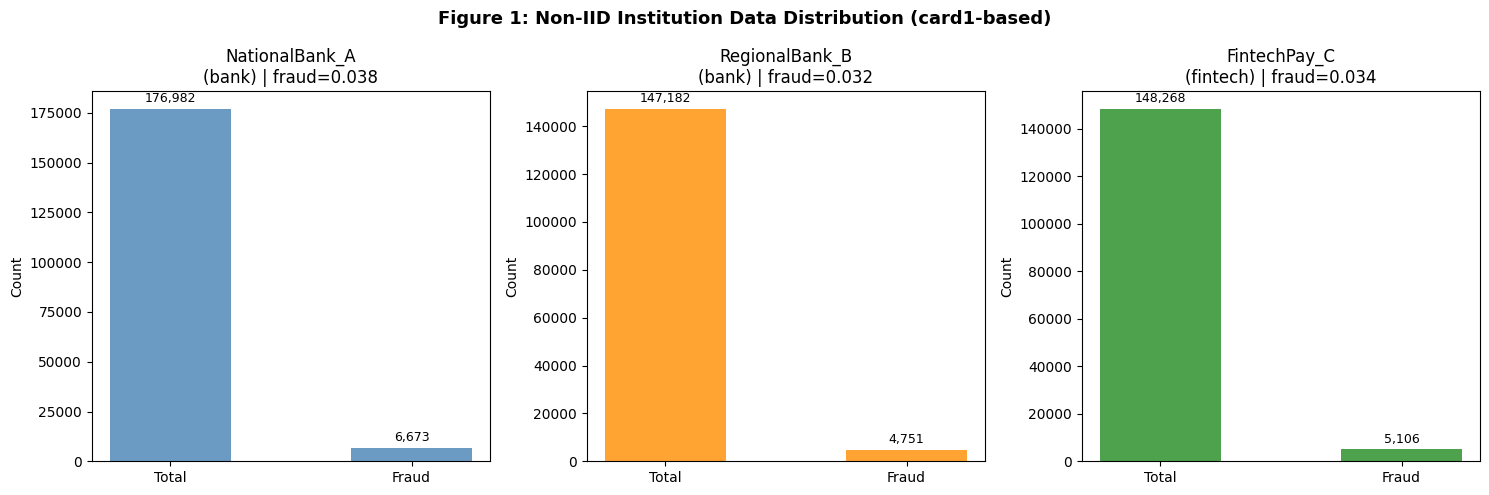

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Figure 1: Non-IID Institution Data Distribution (card1-based)', fontsize=13, fontweight='bold')
colors = ['steelblue', 'darkorange', 'forestgreen']
for ax, cd, color in zip(axes, clients_data, colors):
    labels = ['Total', 'Fraud']
    vals   = [cd['n_samples'], int(cd['n_samples']*cd['fraud_rate'])]
    ax.bar(labels, vals, color=color, alpha=0.8, width=0.5)
    ax.set_title(f'{cd["client_id"]}\n({cd["institution_type"]}) | fraud={cd["fraud_rate"]:.3f}')
    ax.set_ylabel('Count')
    for i, v in enumerate(vals):
        ax.text(i, v + vals[0]*0.01, f'{v:,}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FL_RESULTS, 'fig1_institution_distribution.png'), dpi=100)
plt.show()

## Figure 2 â€” Convergence: AUC per Round (All 3 Algorithms)

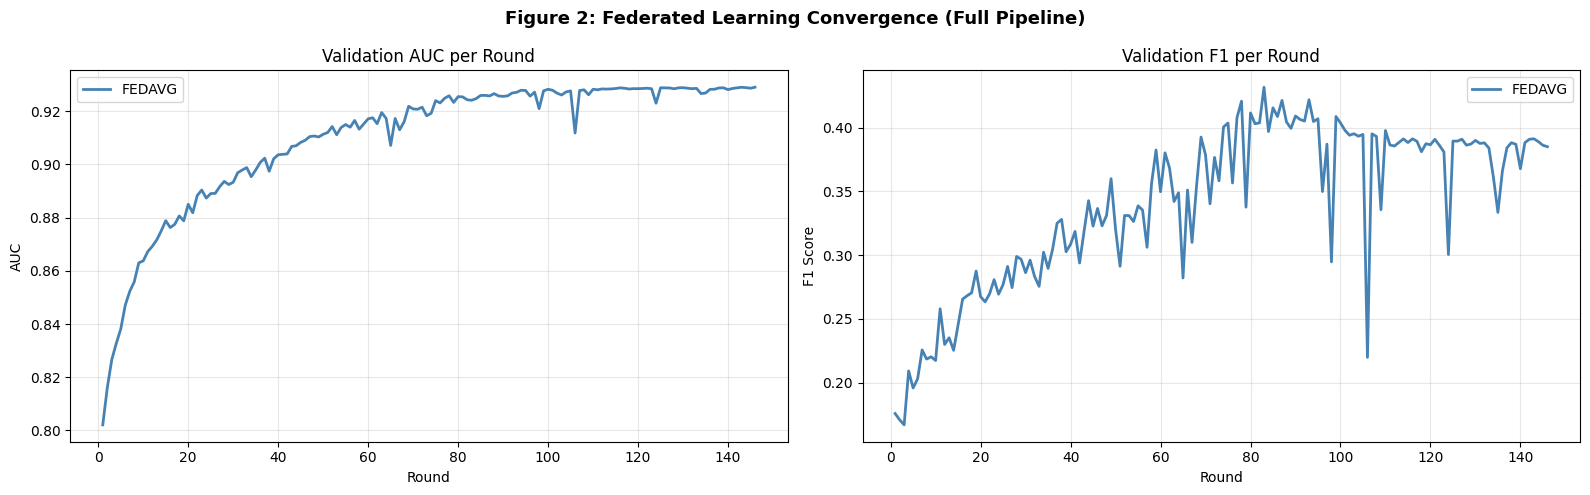

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Figure 2: Federated Learning Convergence (Full Pipeline)', fontsize=13, fontweight='bold')
colors = {'fedavg': 'steelblue', 'fedprox': 'darkorange', 'fednova': 'forestgreen'}
for algo in all_summaries:
    hist = globals().get(f'history_{algo}', [])
    if not hist:
        continue
    rounds = [h['round'] for h in hist]
    label = algo.upper()
    ax1.plot(rounds, [h['auc'] for h in hist], color=colors.get(algo), label=label, linewidth=2)
    ax2.plot(rounds, [h['f1']  for h in hist], color=colors.get(algo), label=label, linewidth=2)
ax1.set_xlabel('Round'); ax1.set_ylabel('AUC')
ax1.set_title('Validation AUC per Round'); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.set_xlabel('Round'); ax2.set_ylabel('F1 Score')
ax2.set_title('Validation F1 per Round'); ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FL_RESULTS, 'fig2_convergence.png'), dpi=100)
plt.show()


## Figure 3 â€” Per-Institution AUC Comparison

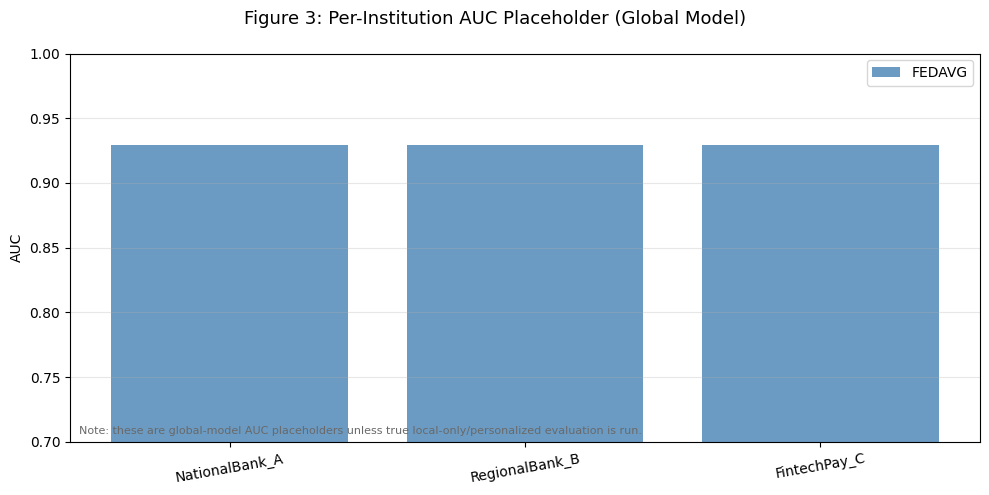

In [42]:
institutions = list(next(iter(all_summaries.values())).get('personalized_aucs', {}).keys())
if institutions:
    x     = np.arange(len(institutions))
    width = 0.8 / max(len(all_summaries), 1)
    fig, ax = plt.subplots(figsize=(10, 5))
    fig.suptitle('Figure 3: Per-Institution AUC Placeholder (Global Model)', fontsize=13)
    colors = {'fedavg': 'steelblue', 'fedprox': 'darkorange', 'fednova': 'forestgreen'}
    for i, (algo, s) in enumerate(all_summaries.items()):
        aucs = [s.get('personalized_aucs', {}).get(inst, np.nan) for inst in institutions]
        ax.bar(x + i*width, aucs, width, label=algo.upper(),
               color=colors.get(algo, None), alpha=0.8)
    ax.set_xticks(x + width*(len(all_summaries)-1)/2)
    ax.set_xticklabels(institutions, rotation=10)
    ax.set_ylabel('AUC')
    ax.set_ylim(0.7, 1.0)
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    ax.text(0.01, 0.02,
            'Note: these are global-model AUC placeholders unless true local-only/personalized evaluation is run.',
            transform=ax.transAxes, fontsize=8, color='dimgray')
    plt.tight_layout()
    plt.savefig(os.path.join(FL_RESULTS, 'fig3_per_institution.png'), dpi=100)
    plt.show()
else:
    print('No per-institution AUC entries found; run local-only/personalized evaluation for Figure 3.')


## Table 1 â€” Algorithm Comparison Summary

In [43]:
print('=' * 110)
print('TABLE 1: Federated Full-Pipeline Algorithm Comparison')
print('Pipeline: FraudTCN + FraudGAT + CaT_GNN + ImprovedDAE + GatedFusion')
print('=' * 110)
print(f'{"Algorithm":12s} {"AUC":>8} {"F1":>8} {"Precision":>10} {"Recall":>8} '
      f'{"Best Rnd":>10} {"TP":>7} {"FP":>7} {"Threshold":>10} {"Final LR":>10}')
print('-' * 110)
for algo, s in all_summaries.items():
    m = s['final_metrics']
    lr_s = s.get('lr_schedule', {}).get('final', {}).get('lr')
    lr_txt = f'{lr_s:.1e}' if isinstance(lr_s, (int, float)) else 'N/A'
    print(f'{algo:12s} {s["best_auc"]:>8.4f} {m["f1"]:>8.4f} '
          f'{m["precision"]:>10.4f} {m["recall"]:>8.4f} '
          f'{s["best_round"]:>10d} {m["tp"]:>7,} {m["fp"]:>7,} '
          f'{s.get("optimal_threshold", m.get("threshold", 0)):>10.3f} {lr_txt:>10}')
print()
print(f'Winner: {best_algo.upper()}  AUC={best_summary["best_auc"]:.4f}')

table = {
    algo: {
        'best_auc': s['best_auc'],
        'best_round': s['best_round'],
        'final_metrics': s['final_metrics'],
        'optimal_threshold': s.get('optimal_threshold', s['final_metrics'].get('threshold')),
        'lr_schedule': s.get('lr_schedule'),
    }
    for algo, s in all_summaries.items()
}
with open(os.path.join(FL_RESULTS, 'table1_comparison.json'), 'w') as f:
    json.dump(table, f, indent=2)
print('Table 1 saved.')


TABLE 1: Federated Full-Pipeline Algorithm Comparison
Pipeline: FraudTCN + FraudGAT + CaT_GNN + ImprovedDAE + GatedFusion
Algorithm         AUC       F1  Precision   Recall   Best Rnd      TP      FP  Threshold   Final LR
--------------------------------------------------------------------------------------------------------------
fedavg         0.9290   0.5966     0.7118   0.5134        146   2,122     859      0.940    1.0e-06

Winner: FEDAVG  AUC=0.9290
Table 1 saved.


## Cell 22 â€” Save Final Results

In [44]:
final_fl = {
    'best_algorithm':       best_algo,
    'best_auc':             best_summary['best_auc'],
    'all_algorithms':       {algo: s['best_auc'] for algo, s in all_summaries.items()},
    'final_metrics':        best_summary['final_metrics'],
    'federated_components': ['FraudTCN', 'FraudGAT', 'CaT_GNN', 'ImprovedDAE', 'GatedFusion'],
    'institutions':         [c['client_id'] for c in clients_data] if 'clients_data' in dir()
                            else list(best_summary['personalized_aucs'].keys()),
}
with open(os.path.join(FL_RESULTS, 'fl_final_metrics.json'), 'w') as f:
    json.dump(final_fl, f, indent=2)

if best_weights is not None:
    torch.save(best_weights, os.path.join(FL_RESULTS, 'models', 'best_pipeline.pt'))
    print('Best weights re-saved to', FL_RESULTS / 'models' / 'best_pipeline.pt')
else:
    print('best_weights not in memory and pt file missing â€” skipping model save')

print('Final FL results saved.')
print(f'Best algorithm : {best_algo.upper()}')
print(f'Best AUC       : {best_summary["best_auc"]:.4f}')
print(f'Final F1       : {best_summary["final_metrics"]["f1"]:.4f}')
print(f'Federated      : FraudTCN + FraudGAT + CaT_GNN + ImprovedDAE + GatedFusion')


Best weights re-saved to /kaggle/working/fl-results/models/best_pipeline.pt
Final FL results saved.
Best algorithm : FEDAVG
Best AUC       : 0.9290
Final F1       : 0.5966
Federated      : FraudTCN + FraudGAT + CaT_GNN + ImprovedDAE + GatedFusion


## Figure 4 â€” Communication Cost Analysis (Model Size Ã— Rounds Ã— Clients)

Model Parameter Counts:
  TCN       :    381,761 params  (1.527 MB)
  GAT       :    101,696 params  (0.407 MB)
  CaT-GNN   :    105,282 params  (0.421 MB)
  DAE       :    621,320 params  (2.485 MB)
  Fusion    :    109,957 params  (0.440 MB)
  TOTAL     :  1,320,016 params  (5.280 MB)
  FEDAVG  : 146 rounds | upload=2312.7MB | download=2312.7MB | total=4625.3MB


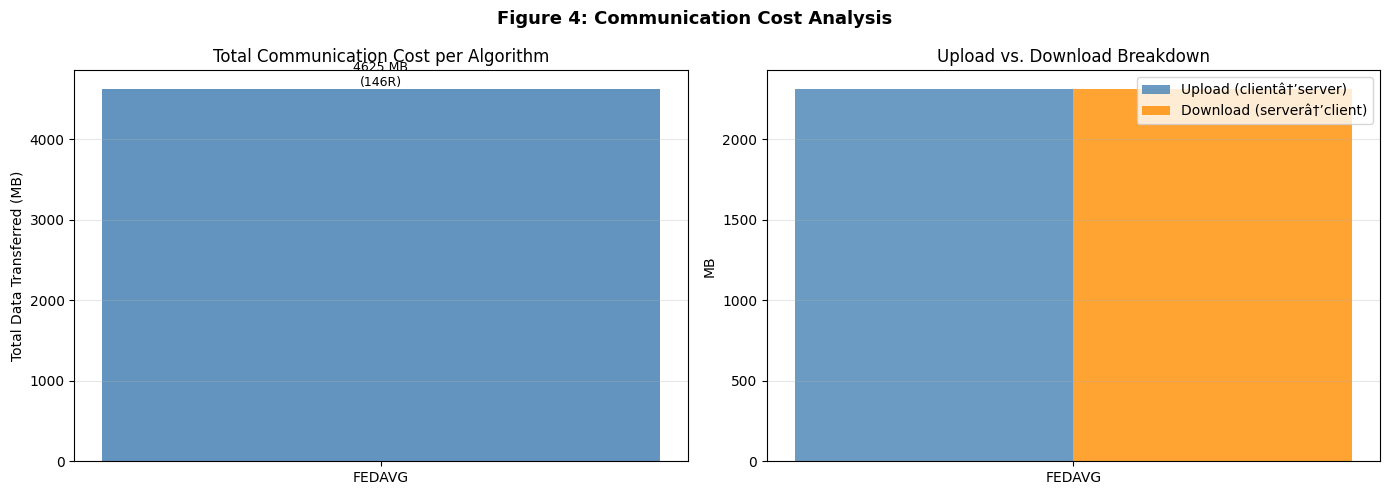

Figure 4 saved.


In [46]:

# â”€â”€ Figure 4: Communication Cost â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Each round: server broadcasts global weights -> clients; clients upload updates -> server.
# Cost = 2 * total_model_params * 4 bytes * num_clients * num_rounds / 1e6  (MB)

def _count_params(model):
    return sum(p.numel() for p in model.parameters())

_models_tmp = {
    'TCN':    FraudTCN(input_dim=FL_CONFIG['input_dim'], embed_dim=FL_CONFIG['embed_dim']),
    'GAT':    FraudGAT(in_dim=FL_CONFIG['input_dim'], hidden_dim=FL_CONFIG['embed_dim']),
    'CaT-GNN': CaT_GNN(in_dim=FL_CONFIG['input_dim'], hidden_dim=FL_CONFIG['embed_dim']),
    'DAE':    ImprovedDAE(input_dim=FL_CONFIG['input_dim'], latent_dim=FL_CONFIG['embed_dim']),
    'Fusion': FusionClassifier(embed_dim=FL_CONFIG['embed_dim']),
}
comp_params = {k: _count_params(m) for k, m in _models_tmp.items()}
total_params = sum(comp_params.values())
param_mb     = total_params * 4 / 1e6   # float32 = 4 bytes

n_clients = len(clients_data) if 'clients_data' in dir() else 3

print('Model Parameter Counts:')
for comp, n in comp_params.items():
    print(f'  {comp:10s}: {n:>10,} params  ({n*4/1e6:.3f} MB)')
print(f'  {"TOTAL":10s}: {total_params:>10,} params  ({param_mb:.3f} MB)')

comm_data = []
for algo, s in all_summaries.items():
    R = s['total_rounds']
    upload_mb   = param_mb * n_clients * R       # clients -> server per round
    download_mb = param_mb * n_clients * R       # server -> clients per round
    total_mb    = upload_mb + download_mb
    comm_data.append({'algo': algo.upper(), 'rounds': R,
                      'upload_mb': upload_mb, 'download_mb': download_mb,
                      'total_mb': total_mb})
    print(f'  {algo.upper():8s}: {R} rounds | upload={upload_mb:.1f}MB | '
          f'download={download_mb:.1f}MB | total={total_mb:.1f}MB')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 4: Communication Cost Analysis', fontsize=13, fontweight='bold')

algos = [d['algo'] for d in comm_data]
x     = np.arange(len(algos))
colors = ['steelblue', 'darkorange', 'forestgreen']

bars = axes[0].bar(algos, [d['total_mb'] for d in comm_data], color=colors, alpha=0.85)
axes[0].set_ylabel('Total Data Transferred (MB)')
axes[0].set_title('Total Communication Cost per Algorithm')
axes[0].grid(True, alpha=0.3, axis='y')
for bar, d in zip(bars, comm_data):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{d["total_mb"]:.0f} MB\n({d["rounds"]}R)', ha='center', va='bottom', fontsize=9)

w = 0.35
axes[1].bar(x - w/2, [d['upload_mb']   for d in comm_data], w, label='Upload (clientâ†’server)',   color='steelblue',  alpha=0.8)
axes[1].bar(x + w/2, [d['download_mb'] for d in comm_data], w, label='Download (serverâ†’client)', color='darkorange', alpha=0.8)
axes[1].set_xticks(x); axes[1].set_xticklabels(algos)
axes[1].set_ylabel('MB'); axes[1].set_title('Upload vs. Download Breakdown')
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(FL_RESULTS / 'fig4_communication_cost.png', dpi=100)
plt.show()

comm_df = {d['algo']: d for d in comm_data}
comm_df['model_mb'] = param_mb
comm_df['total_params'] = total_params
with open(FL_RESULTS / 'communication_cost.json', 'w') as f:
    json.dump(comm_df, f, indent=2)
print('Figure 4 saved.')


## Figure 5 â€” Rounds-to-Convergence & Per-Round Timing

Rounds-to-Convergence Table:
Algorithm   >= 80%  >= 82%  >= 84%  >= 86%  >= 90%   Peak AUC   Avg s/rnd
-------------------------------------------------------------------------
FEDAVG           1       3       6       9      36     0.9290        85.8s


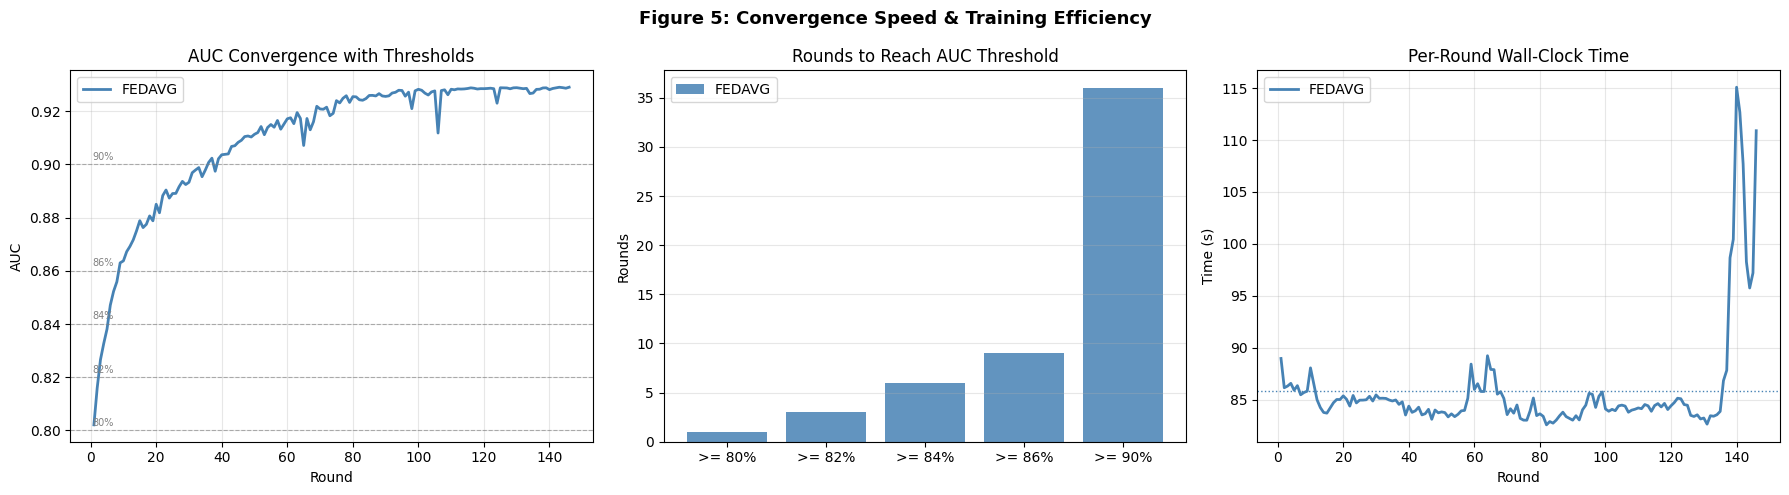

Figure 5 saved.


In [47]:
# ── Figure 5: Rounds-to-Convergence + Per-Round Timing ───────────────────────────────────────
algo_histories = {algo.upper(): globals().get(f'history_{algo}', [])
                  for algo in all_summaries}
algo_histories = {algo: hist for algo, hist in algo_histories.items() if hist}
colors_map = {'FEDAVG': 'steelblue', 'FEDPROX': 'darkorange', 'FEDNOVA': 'forestgreen'}

thresholds_to_check = [0.80, 0.82, 0.84, 0.86, 0.90]

convergence_table = {}
for algo, hist in algo_histories.items():
    aucs = [h['auc'] for h in hist]
    row  = {}
    for thr in thresholds_to_check:
        crossed = next((h['round'] for h in hist if h['auc'] >= thr), None)
        row[f'rounds_to_{thr:.0%}'] = crossed if crossed else '>' + str(len(hist))
    row['final_auc']  = aucs[-1]
    row['peak_auc']   = max(aucs)
    row['avg_time_s'] = float(np.mean([h['time_s'] for h in hist]))
    row['total_rounds'] = len(hist)
    convergence_table[algo] = row

print('Rounds-to-Convergence Table:')
header = f'{"Algorithm":10s}' + ''.join(f'  >= {t:.0%}' for t in thresholds_to_check) +          f'  {"Peak AUC":>9}  {"Avg s/rnd":>10}'
print(header)
print('-' * len(header))
for algo, row in convergence_table.items():
    cols = ''.join(f'  {str(row[f"rounds_to_{t:.0%}"]):>6}' for t in thresholds_to_check)
    print(f'{algo:10s}{cols}  {row["peak_auc"]:>9.4f}  {row["avg_time_s"]:>10.1f}s')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Figure 5: Convergence Speed & Training Efficiency', fontsize=13, fontweight='bold')

ax = axes[0]
for algo, hist in algo_histories.items():
    rounds = [h['round'] for h in hist]
    ax.plot(rounds, [h['auc'] for h in hist], color=colors_map.get(algo), label=algo, linewidth=2)
for thr in thresholds_to_check:
    ax.axhline(thr, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.text(0.5, thr + 0.001, f'{thr:.0%}', color='gray', fontsize=7, va='bottom')
ax.set_xlabel('Round'); ax.set_ylabel('AUC')
ax.set_title('AUC Convergence with Thresholds'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
x = np.arange(len(thresholds_to_check))
width = 0.8 / max(len(convergence_table), 1)
for i, (algo, row) in enumerate(convergence_table.items()):
    vals = []
    for t in thresholds_to_check:
        v = row[f'rounds_to_{t:.0%}']
        vals.append(int(str(v).replace('>', '')) if isinstance(v, str) else v)
    ax.bar(x + i*width, vals, width, label=algo, color=colors_map.get(algo), alpha=0.85)
ax.set_xticks(x + width*(len(convergence_table)-1)/2)
ax.set_xticklabels([f'>= {t:.0%}' for t in thresholds_to_check])
ax.set_ylabel('Rounds'); ax.set_title('Rounds to Reach AUC Threshold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')

ax = axes[2]
for algo, hist in algo_histories.items():
    rounds = [h['round'] for h in hist]
    times  = [h['time_s'] for h in hist]
    ax.plot(rounds, times, color=colors_map.get(algo), label=algo, linewidth=2)
    ax.axhline(np.mean(times), color=colors_map.get(algo), linestyle=':', linewidth=1)
ax.set_xlabel('Round'); ax.set_ylabel('Time (s)')
ax.set_title('Per-Round Wall-Clock Time'); ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FL_RESULTS / 'fig5_convergence_timing.png', dpi=100)
plt.show()

with open(FL_RESULTS / 'convergence_analysis.json', 'w') as f:
    json.dump(convergence_table, f, indent=2)
print('Figure 5 saved.')


## Table 2 â€” Extended Comparison: Federated vs. Centralized vs. Local-Only Baselines

In [48]:
# ── Table 2: Centralized vs Federated vs Local-Only ─────────────────────────────────
# This cell no longer uses the old "worst FL algorithm" local-only proxy.
# If local-only results exist, they are loaded. Otherwise the table marks local-only as not run.

RUN_LOCAL_ONLY_BASELINE = True  # Set True to run the expensive true local-only baseline.


def _project_candidates(*relative_parts):
    roots = [
        Path.cwd(),
        Path.cwd().parent,
        Path('/teamspace/studios/this_studio'),
        Path('/kaggle/working'),
        Path('/kaggle/input'),
        Path('C:/Users/sorat/Downloads/DA'),
    ]
    return [root.joinpath(*relative_parts) for root in roots]


def _try_load_central():
    candidates = []
    candidates += _project_candidates('Final', 'Results', 'results_final_fusion_valSet', 'fusion_metrics.json')
    candidates += _project_candidates('results_final_fusion_valSet', 'fusion_metrics.json')
    candidates += _project_candidates('fusion_results', 'fusion_metrics.json')
    candidates += _project_candidates('results_final_fusion_valSet', 'fusion_results', 'fusion_evaluation_comprehensive.json')
    candidates += _project_candidates('fusion_results', 'fusion_evaluation_comprehensive.json')
    for p in candidates:
        if p.exists():
            with open(p) as f:
                d = json.load(f)
            metrics = {
                'auc':       d.get('xgb_auc') or d.get('roc_auc') or d.get('auc') or d.get('best_auc'),
                'f1':        d.get('xgb_f1') or d.get('f1'),
                'precision': d.get('xgb_precision') or d.get('precision'),
                'recall':    d.get('xgb_recall') or d.get('recall'),
                'threshold': d.get('xgb_threshold') or d.get('threshold'),
            }
            if metrics['auc'] is not None:
                return {k: (float(v) if v is not None else None) for k, v in metrics.items()}, str(p)
    return None, None


def _try_load_local_only():
    candidates = [FL_RESULTS / 'local_only' / 'summary.json']
    candidates += _project_candidates('Final', 'Results', 'fed_results', 'local_only', 'summary.json')
    for p in candidates:
        if p.exists():
            with open(p) as f:
                return json.load(f), str(p)
    return None, None


def run_local_only_baseline(clients, global_g, val_nids, config, device, results_dir):
    """Train one full pipeline per institution without aggregation, then report mean AUC."""
    local_dir = results_dir / 'local_only'
    os.makedirs(local_dir / 'models', exist_ok=True)
    rows = []
    round_lrs = {
        'lr': config['lr'],
        'dae_pretrain_lr': config['dae_pretrain_lr'],
        'dae_finetune_lr': config['dae_finetune_lr'],
    }
    for client in clients:
        print(f'\nLOCAL-ONLY: {client.client_id}')
        client.reset_model()
        init_w = make_global_weights(config)
        update = client.train_local(init_w, algorithm='fedavg', mu=0.0,
                                    local_epochs=config['local_epochs'], round_lrs=round_lrs)
        w_i = update['weights']                          # ← unwrap the weights
        opt_thr = find_optimal_threshold(w_i, global_g, val_nids, device, config)
        m = evaluate_global_pipeline(w_i, global_g, val_nids, device, config, threshold=opt_thr)
        rows.append({'client_id': client.client_id, 'institution_type': client.institution_type,
                     'n_samples': client.n_samples, 'fraud_rate': float(client.y.mean()),
                     'optimal_threshold': opt_thr, 'metrics': m})
        torch.save(w_i, local_dir / 'models' / f'{client.client_id}_pipeline.pt')
        print(f'  AUC={m["auc"]:.4f} F1={m["f1"]:.4f} P={m["precision"]:.4f} R={m["recall"]:.4f}')

    summary = {
        'setting': 'local_only_true',
        'mean_auc': float(np.mean([r['metrics']['auc'] for r in rows])),
        'mean_f1': float(np.mean([r['metrics']['f1'] for r in rows])),
        'mean_precision': float(np.mean([r['metrics']['precision'] for r in rows])),
        'mean_recall': float(np.mean([r['metrics']['recall'] for r in rows])),
        'clients': rows,
    }
    with open(local_dir / 'summary.json', 'w') as f:
        json.dump(summary, f, indent=2)
    print('Local-only summary saved ->', local_dir / 'summary.json')
    return summary


if RUN_LOCAL_ONLY_BASELINE:
    local_only_summary = run_local_only_baseline(
        fl_clients, global_g, val_nids_g, FL_CONFIG, DEVICE, FL_RESULTS)
else:
    local_only_summary, local_src = _try_load_local_only()
    if local_only_summary:
        print(f'Local-only results loaded from {local_src}')
    else:
        print('Local-only true baseline not found. Set RUN_LOCAL_ONLY_BASELINE=True to generate it.')

central_metrics, central_src = _try_load_central()
if central_metrics:
    print(f'Centralized metrics loaded from {central_src}: AUC={central_metrics["auc"]:.4f}')
else:
    print('Centralized result not found; Table 2 will mark centralized as N/A.')

best_fl_auc = best_summary['best_auc']
best_fl_f1  = best_summary['final_metrics']['f1']
best_fl_p   = best_summary['final_metrics']['precision']
best_fl_r   = best_summary['final_metrics']['recall']

rows = []
rows.append({
    'setting': 'Centralized XGBoost Fusion',
    'auc': central_metrics['auc'] if central_metrics else None,
    'f1': central_metrics['f1'] if central_metrics else None,
    'precision': central_metrics['precision'] if central_metrics else None,
    'recall': central_metrics['recall'] if central_metrics else None,
    'privacy': 'None',
    'data_sharing': 'Full data pooled',
    'source': central_src,
})
rows.append({
    'setting': f'FL-Best ({best_algo.upper()})',
    'auc': best_fl_auc,
    'f1': best_fl_f1,
    'precision': best_fl_p,
    'recall': best_fl_r,
    'privacy': 'Weights',
    'data_sharing': 'Model updates only',
    'source': str(FL_RESULTS / best_algo / 'summary.json'),
})
for algo, s in all_summaries.items():
    m = s['final_metrics']
    rows.append({
        'setting': f'FL-{algo.upper()}',
        'auc': s['best_auc'],
        'f1': m['f1'],
        'precision': m['precision'],
        'recall': m['recall'],
        'privacy': 'Weights',
        'data_sharing': 'Model updates only',
        'source': str(FL_RESULTS / algo / 'summary.json'),
    })
if local_only_summary:
    rows.append({
        'setting': 'Local-Only (true mean)',
        'auc': local_only_summary.get('mean_auc'),
        'f1': local_only_summary.get('mean_f1'),
        'precision': local_only_summary.get('mean_precision'),
        'recall': local_only_summary.get('mean_recall'),
        'privacy': 'Local',
        'data_sharing': 'None',
        'source': str(FL_RESULTS / 'local_only' / 'summary.json'),
    })
else:
    rows.append({
        'setting': 'Local-Only (not run)',
        'auc': None, 'f1': None, 'precision': None, 'recall': None,
        'privacy': 'Local', 'data_sharing': 'None', 'source': None,
    })

print()
print('=' * 112)
print('TABLE 2: System-Level Comparison (Full Pipeline: TCN + GAT + CaT-GNN + DAE + GatedFusion)')
print('=' * 112)
print(f'{"Setting":32s} {"AUC":>8} {"F1":>8} {"Precision":>10} {"Recall":>8} '
      f'{"Privacy":>10} {"Data Sharing":>18}')
print('-' * 112)
for r in rows:
    fmt = lambda v: f'{v:.4f}' if isinstance(v, (int, float)) and not np.isnan(v) else 'N/A'
    print(f'{r["setting"]:32s} {fmt(r["auc"]):>8} {fmt(r["f1"]):>8} '
          f'{fmt(r["precision"]):>10} {fmt(r["recall"]):>8} '
          f'{r["privacy"]:>10} {r["data_sharing"]:>18}')

print()
if central_metrics:
    gap = best_fl_auc - central_metrics['auc']
    print(f'Federated-Centralized AUC gap: {gap:+.4f} ' +
          ('(privacy cost)' if gap < 0 else '(FL surplus)'))
if local_only_summary:
    gap_local = best_fl_auc - local_only_summary['mean_auc']
    print(f'Federation benefit over true local-only: {gap_local:+.4f} AUC')
else:
    print('Local-only benefit not computed because true local-only baseline has not been run.')

table2 = {'rows': rows, 'notes': {
    'centralized_source': central_src,
    'local_only_is_true_baseline': bool(local_only_summary),
    'local_only_instruction': 'Set RUN_LOCAL_ONLY_BASELINE=True in this cell to generate local-only results.',
}}  
with open(FL_RESULTS / 'table2_system_comparison.json', 'w') as f:
    json.dump(table2, f, indent=2)
print('Table 2 saved ->', FL_RESULTS / 'table2_system_comparison.json')



LOCAL-ONLY: NationalBank_A
  AUC=0.8081 F1=0.2904 P=0.2768 R=0.3053

LOCAL-ONLY: RegionalBank_B
  AUC=0.8018 F1=0.2694 P=0.2460 R=0.2976

LOCAL-ONLY: FintechPay_C
  AUC=0.8035 F1=0.2682 P=0.2661 R=0.2703
Local-only summary saved -> /kaggle/working/fl-results/local_only/summary.json
Centralized result not found; Table 2 will mark centralized as N/A.

TABLE 2: System-Level Comparison (Full Pipeline: TCN + GAT + CaT-GNN + DAE + GatedFusion)
Setting                               AUC       F1  Precision   Recall    Privacy       Data Sharing
----------------------------------------------------------------------------------------------------------------
Centralized XGBoost Fusion            N/A      N/A        N/A      N/A       None   Full data pooled
FL-Best (FEDAVG)                   0.9290   0.5966     0.7118   0.5134    Weights Model updates only
FL-FEDAVG                          0.9290   0.5966     0.7118   0.5134    Weights Model updates only
Local-Only (true mean)             0.804

## Figure 6 â€” Privacy & Data Sharing Summary (paper narrative cell)

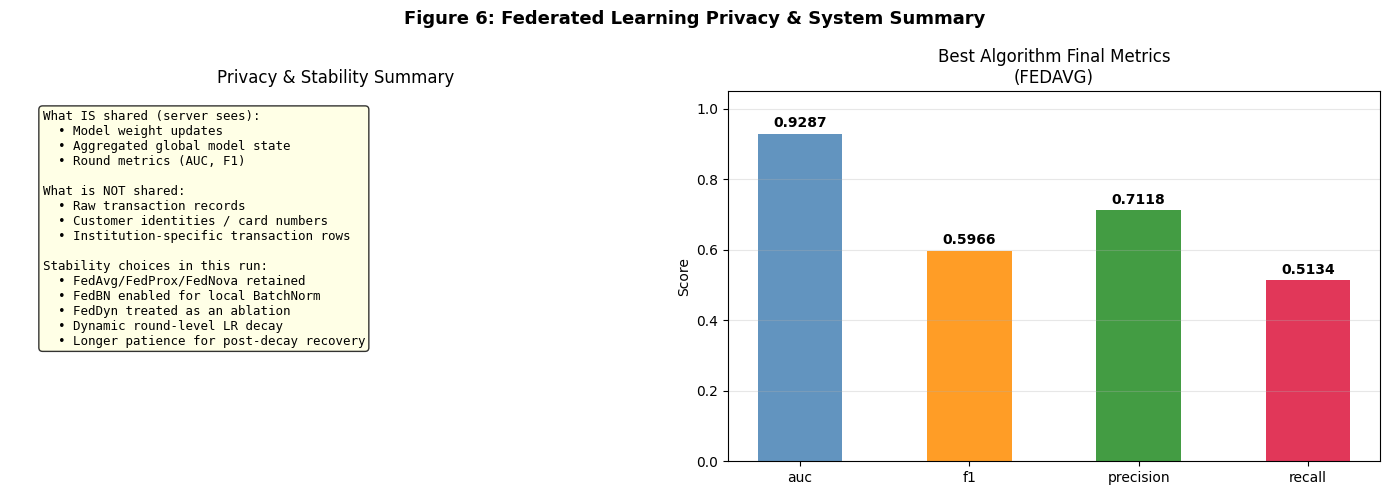


FINAL PAPER SUMMARY — Federated Full-Pipeline Fraud Detection
Best algorithm   : FEDAVG
Best AUC         : 0.9290
Best round       : 146 / 146
Optimal threshold: 0.940
Final LR         : 1.00e-06

Final metrics at optimal threshold:
  auc         : 0.9287
  f1          : 0.5966
  precision   : 0.7118
  recall      : 0.5134

Confusion matrix:
  TP=2,122  FP=859  TN=113,116  FN=2,011

Outputs saved to: /kaggle/working/fl-results
  fig1_institution_distribution.png
  fig2_convergence.png
  fig3_per_institution.png
  fig4_communication_cost.png
  fig5_convergence_timing.png
  fig6_privacy_summary.png
  table1_comparison.json
  table2_system_comparison.json
  communication_cost.json
  convergence_analysis.json


In [49]:
# ── Figure 6: Privacy Guarantee & Final Summary ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 6: Federated Learning Privacy & System Summary', fontsize=13, fontweight='bold')

ax = axes[0]
ax.axis('off')
shared_text = (
    "What IS shared (server sees):\n"
    "  • Model weight updates\n"
    "  • Aggregated global model state\n"
    "  • Round metrics (AUC, F1)\n\n"
    "What is NOT shared:\n"
    "  • Raw transaction records\n"
    "  • Customer identities / card numbers\n"
    "  • Institution-specific transaction rows\n\n"
    "Stability choices in this run:\n"
    "  • FedAvg/FedProx/FedNova retained\n"
    "  • FedBN enabled for local BatchNorm\n  • FedDyn treated as an ablation\n"
    "  • Dynamic round-level LR decay\n"
    "  • Longer patience for post-decay recovery"
)
ax.text(0.05, 0.95, shared_text, transform=ax.transAxes,
        fontsize=9, verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
ax.set_title('Privacy & Stability Summary')

ax = axes[1]
metrics_to_show = ['auc', 'f1', 'precision', 'recall']
vals = [best_summary['final_metrics'][m] for m in metrics_to_show]
bar_colors = ['steelblue', 'darkorange', 'forestgreen', 'crimson']
bars = ax.bar(metrics_to_show, vals, color=bar_colors, alpha=0.85, width=0.5)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title(f'Best Algorithm Final Metrics\n({best_algo.upper()})')
ax.grid(True, alpha=0.3, axis='y')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(FL_RESULTS / 'fig6_privacy_summary.png', dpi=100)
plt.show()

print()
print('=' * 70)
print('FINAL PAPER SUMMARY — Federated Full-Pipeline Fraud Detection')
print('=' * 70)
print(f'Best algorithm   : {best_algo.upper()}')
print(f'Best AUC         : {best_summary["best_auc"]:.4f}')
print(f'Best round       : {best_summary["best_round"]} / {best_summary["total_rounds"]}')
print(f'Optimal threshold: {best_summary["optimal_threshold"]:.3f}')
if best_summary.get('lr_schedule'):
    print(f'Final LR         : {best_summary["lr_schedule"]["final"]["lr"]:.2e}')
print()
print('Final metrics at optimal threshold:')
for k in ['auc', 'f1', 'precision', 'recall']:
    print(f'  {k:12s}: {best_summary["final_metrics"][k]:.4f}')
print()
print('Confusion matrix:')
m = best_summary['final_metrics']
print(f'  TP={m["tp"]:,}  FP={m["fp"]:,}  TN={m["tn"]:,}  FN={m["fn"]:,}')
print()
print('Outputs saved to:', FL_RESULTS)
for fname in ['fig1_institution_distribution.png', 'fig2_convergence.png',
              'fig3_per_institution.png', 'fig4_communication_cost.png',
              'fig5_convergence_timing.png', 'fig6_privacy_summary.png',
              'table1_comparison.json', 'table2_system_comparison.json',
              'communication_cost.json', 'convergence_analysis.json']:
    print(f'  {fname}')
